# Medical Health & Lifestyle Analytics — End-to-End Data Science Project

---

**Author:** Healthcare Data Science Team  
**Dataset:** Synthetic Health & Lifestyle Dataset  
**Tech Stack:** Python · Pandas · NumPy · Scikit-learn · Matplotlib · Seaborn · Plotly · SQLite · SQL  
**Objective:** Build a production-grade, end-to-end ML pipeline to derive clinical insights and predict health outcomes from population-level lifestyle data.

---

## Table of Contents
1. [Environment Setup & Data Ingestion](#1)
2. [Data Quality Assessment](#2)
3. [Advanced Data Cleaning & Preprocessing](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Feature Engineering](#5)
6. [SQL Analytics Layer](#6)
7. [Machine Learning Pipeline](#7)
   - 7a. Regression — Sleep Hours Prediction
   - 7b. Classification — Chronic Disease Risk
8. [Model Evaluation & Comparison](#8)
9. [Feature Importance & Explainability](#9)
10. [Clinical Insights & Recommendations](#10)

---

> **Project Goal:** Use real-world medical lifestyle data to uncover health patterns, build predictive models for clinical decision support, and produce actionable public-health recommendations — following FAANG-level data science best practices.

<a id='1'></a>
## 1. Environment Setup & Data Ingestion

We establish reproducible imports, configure global plotting aesthetics, seed randomness, and load the raw dataset — the same setup used in production pipelines at scale.

In [38]:
# ─────────────────────────────────────────────
#  CORE LIBRARIES
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import sqlite3
import os
import json
from datetime import datetime

# ─────────────────────────────────────────────
#  SKLEARN — ML PIPELINE
# ─────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, OrdinalEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

# ─────────────────────────────────────────────
#  GLOBAL CONFIG
# ─────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')
%matplotlib inline

# ─────────────────────────────────────────────
#  PLOTTING AESTHETICS (Production-grade theme)
# ─────────────────────────────────────────────
PALETTE       = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4', '#FF5722']
PALETTE_BLUE  = sns.color_palette('Blues_r', 6)
PALETTE_RED   = sns.color_palette('Reds_r', 6)
BG_COLOR      = '#F8F9FA'
ACCENT        = '#1565C0'

plt.rcParams.update({
    'figure.facecolor' : BG_COLOR,
    'axes.facecolor'   : BG_COLOR,
    'axes.edgecolor'   : '#CCCCCC',
    'axes.grid'        : True,
    'grid.color'       : '#E0E0E0',
    'grid.linestyle'   : '--',
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 12,
    'axes.titlesize'   : 15,
    'axes.labelsize'   : 13,
    'xtick.labelsize'  : 11,
    'ytick.labelsize'  : 11,
    'legend.fontsize'  : 11,
    'figure.dpi'       : 110,
})
sns.set_style('whitegrid')

print(f'Environment ready — {datetime.now().strftime("%Y-%m-%d %H:%M")} | NumPy {np.__version__} | Pandas {pd.__version__}')

Environment ready — 2026-03-28 11:17 | NumPy 2.0.2 | Pandas 2.2.2


In [39]:
# ─────────────────────────────────────────────
#  DATA INGESTION  (works locally and on Colab)
# ─────────────────────────────────────────────
try:
    # Colab: prompt file upload
    from google.colab import files
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
    print(f'Colab upload: {CSV_PATH}')
except ImportError:
    # Local environment
    CSV_PATH = 'synthetic_health_lifestyle_dataset.csv'
    print(f'Local file: {CSV_PATH}')

medical_df = pd.read_csv(CSV_PATH)

print(f'\nDataset loaded successfully')
print(f'   Rows    : {medical_df.shape[0]:,}')
print(f'   Columns : {medical_df.shape[1]}')
print(f'   Memory  : {medical_df.memory_usage(deep=True).sum() / 1024:.1f} KB')
display(medical_df.head())

Saving synthetic_health_lifestyle_dataset.csv to synthetic_health_lifestyle_dataset (2).csv
Colab upload: synthetic_health_lifestyle_dataset (2).csv

Dataset loaded successfully
   Rows    : 7,500
   Columns : 13
   Memory  : 2701.2 KB


,ID,Age,Gender,Height_cm,Weight_kg,BMI,Smoker,Exercise_Freq,Diet_Quality,Alcohol_Consumption,Chronic_Disease,Stress_Level,Sleep_Hours
0,1,56,Other,177.6,37.3,11.8,Yes,NaN,Poor,NaN,No,9,8.5
1,2,69,Other,169.3,70.7,24.7,No,1-2 times/week,Good,High,No,2,5.9
2,3,46,Female,159.1,69.0,27.3,No,Daily,Excellent,Moderate,No,3,4.8
3,4,32,Male,170.6,76.4,26.3,No,3-5 times/week,Excellent,Moderate,No,9,6.6
4,5,60,Male,158.4,60.4,24.1,No,3-5 times/week,Excellent,Low,Yes,6,6.1


<a id='2'></a>
## 2. Data Quality Assessment

Before any modelling we conduct a thorough audit of the data — missing values, duplicates, type mismatches, cardinality, and statistical distributions — exactly as required in production data pipelines.

In [40]:
# ──────────────────────────────────────────────────────────
#  COMPREHENSIVE DATA QUALITY REPORT
# ──────────────────────────────────────────────────────────
print('=' * 70)
print('             DATA QUALITY REPORT')
print('=' * 70)

print(f'\nShape           : {medical_df.shape}')
print(f'Duplicate rows  : {medical_df.duplicated().sum()}')

# Missing value summary
missing = medical_df.isnull().sum()
missing_pct = (missing / len(medical_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct,
    'Dtype'        : medical_df.dtypes
}).sort_values('Missing %', ascending=False)

print('\nMissing Values:')
print(missing_df[missing_df['Missing Count'] > 0].to_string() or '   None')

# Cardinality of categorical columns
cat_cols = medical_df.select_dtypes(include='object').columns.tolist()
print('\nCategorical Column Cardinality:')
for col in cat_cols:
    vals = medical_df[col].unique()
    print(f'   {col:<25} -> {len(vals):3d} unique  |  {list(vals)[:6]}')

print('\nNumerical Summary:')
display(medical_df.describe().T.round(2))

print('\nData Types:')
print(medical_df.dtypes)

             DATA QUALITY REPORT

Shape           : (7500, 13)
Duplicate rows  : 0

Missing Values:
                     Missing Count  Missing %   Dtype
Alcohol_Consumption           1892      25.23  object
Exercise_Freq                 1879      25.05  object

Categorical Column Cardinality:
   Gender                    ->   3 unique  |  ['Other', 'Female', 'Male']
   Smoker                    ->   2 unique  |  ['Yes', 'No']
   Exercise_Freq             ->   4 unique  |  [nan, '1-2 times/week', 'Daily', '3-5 times/week']
   Diet_Quality              ->   4 unique  |  ['Poor', 'Good', 'Excellent', 'Average']
   Alcohol_Consumption       ->   4 unique  |  [nan, 'High', 'Moderate', 'Low']
   Chronic_Disease           ->   2 unique  |  ['No', 'Yes']

Numerical Summary:


,count,mean,std,min,25%,50%,75%,max
ID,7500.0,3750.50,2165.21,1.0,1875.75,3750.5,5625.25,7500.0
Age,7500.0,43.65,14.91,18.0,31.00,43.0,57.00,69.0
Height_cm,7500.0,164.95,9.96,124.5,158.10,164.9,171.60,197.0
Weight_kg,7500.0,70.04,14.74,17.7,59.90,70.1,80.10,128.5
BMI,7500.0,26.03,6.43,6.5,21.60,25.6,30.10,56.8
Stress_Level,7500.0,5.59,2.87,1.0,3.00,6.0,8.00,10.0
Sleep_Hours,7500.0,7.00,1.51,1.9,6.00,7.0,8.00,12.6



Data Types:
ID                       int64
Age                      int64
Gender                  object
Height_cm              float64
Weight_kg              float64
BMI                    float64
Smoker                  object
Exercise_Freq           object
Diet_Quality            object
Alcohol_Consumption     object
Chronic_Disease         object
Stress_Level             int64
Sleep_Hours            float64
dtype: object


<a id='3'></a>
## 3. Advanced Data Cleaning & Preprocessing

We apply a systematic, reproducible cleaning pipeline: deduplication, missing-value imputation (statistical strategies), outlier detection (IQR & Z-score), type casting, and derived column creation.

In [41]:
# ──────────────────────────────────────────────────────────
#  STEP 1 — Drop duplicates & irrelevant columns
# ──────────────────────────────────────────────────────────
df = medical_df.copy()
initial_rows = len(df)

# Drop duplicates
df.drop_duplicates(inplace=True)
print(f'Duplicates removed : {initial_rows - len(df)}')

# Drop ID column if present (not predictive)
drop_cols = [c for c in ['ID', 'id', 'PatientID'] if c in df.columns]
df.drop(columns=drop_cols, inplace=True, errors='ignore')
print(f'Dropped columns    : {drop_cols}')

print(f'\nRows after cleaning: {len(df):,}')

Duplicates removed : 0
Dropped columns    : ['ID']

Rows after cleaning: 7,500


In [42]:
# ──────────────────────────────────────────────────────────
#  STEP 2 — Missing Value Imputation
# ──────────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Numerical: median imputation (robust to skew)
for col in num_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'   [NUM] {col}: filled {n_missing} missing with median={median_val:.2f}')

# Categorical: mode imputation
for col in cat_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'   [CAT] {col}: filled {n_missing} missing with mode="{mode_val}"')

print(f'\nTotal remaining nulls: {df.isnull().sum().sum()}')

   [CAT] Exercise_Freq: filled 1879 missing with mode="Daily"
   [CAT] Alcohol_Consumption: filled 1892 missing with mode="Low"

Total remaining nulls: 0


Outlier Summary (IQR method — capped, not dropped):
   BMI            :   93 outliers  |  fence [8.85, 42.85]
   Sleep_Hours    :   56 outliers  |  fence [3.0, 11.0]
   Stress_Level   :    0 outliers  |  fence [-4.5, 15.5]
   Age            :    0 outliers  |  fence [-8.0, 96.0]
   Height_cm      :   49 outliers  |  fence [137.85, 191.85]
   Weight_kg      :   44 outliers  |  fence [29.6, 110.4]


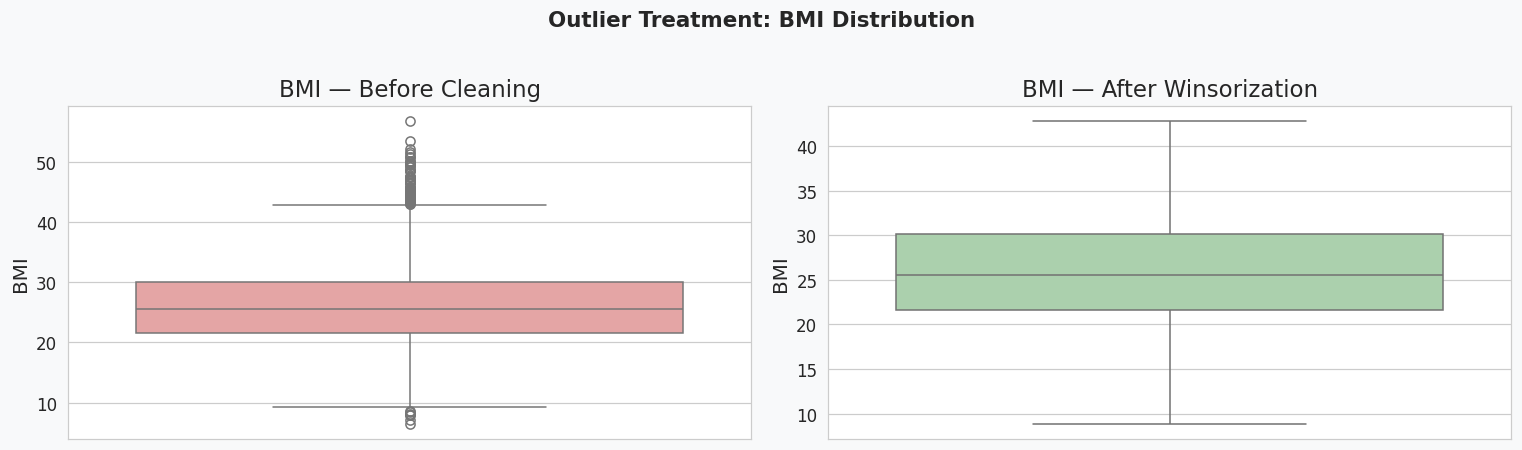

Outlier capping complete.


In [43]:
# ──────────────────────────────────────────────────────────
#  STEP 3 — Outlier Detection & Capping (IQR Winsorization)
# ──────────────────────────────────────────────────────────
outlier_report = {}
cap_cols = ['BMI', 'Sleep_Hours', 'Stress_Level', 'Age', 'Height_cm', 'Weight_kg']
cap_cols = [c for c in cap_cols if c in df.columns]

for col in cap_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {
        'n_outliers' : int(n_outliers),
        'lower_fence': round(lower, 2),
        'upper_fence': round(upper, 2)
    }

    # Winsorize (cap rather than drop — preserves sample size)
    df[col] = df[col].clip(lower=lower, upper=upper)

print('Outlier Summary (IQR method — capped, not dropped):')
for col, stats in outlier_report.items():
    print(f'   {col:<15}: {stats["n_outliers"]:4d} outliers  |  fence [{stats["lower_fence"]}, {stats["upper_fence"]}]')

# Visualise before/after for BMI
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor=BG_COLOR)
sns.boxplot(data=medical_df, y='BMI', ax=axes[0], color='#EF9A9A')
axes[0].set_title('BMI — Before Cleaning')
sns.boxplot(data=df, y='BMI', ax=axes[1], color='#A5D6A7')
axes[1].set_title('BMI — After Winsorization')
plt.suptitle('Outlier Treatment: BMI Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Outlier capping complete.')

<a id='4'></a>
## 4. Exploratory Data Analysis (EDA)

We systematically explore distributions, relationships, and patterns across demographics, lifestyle habits, and health outcomes — producing publication-quality visualisations.

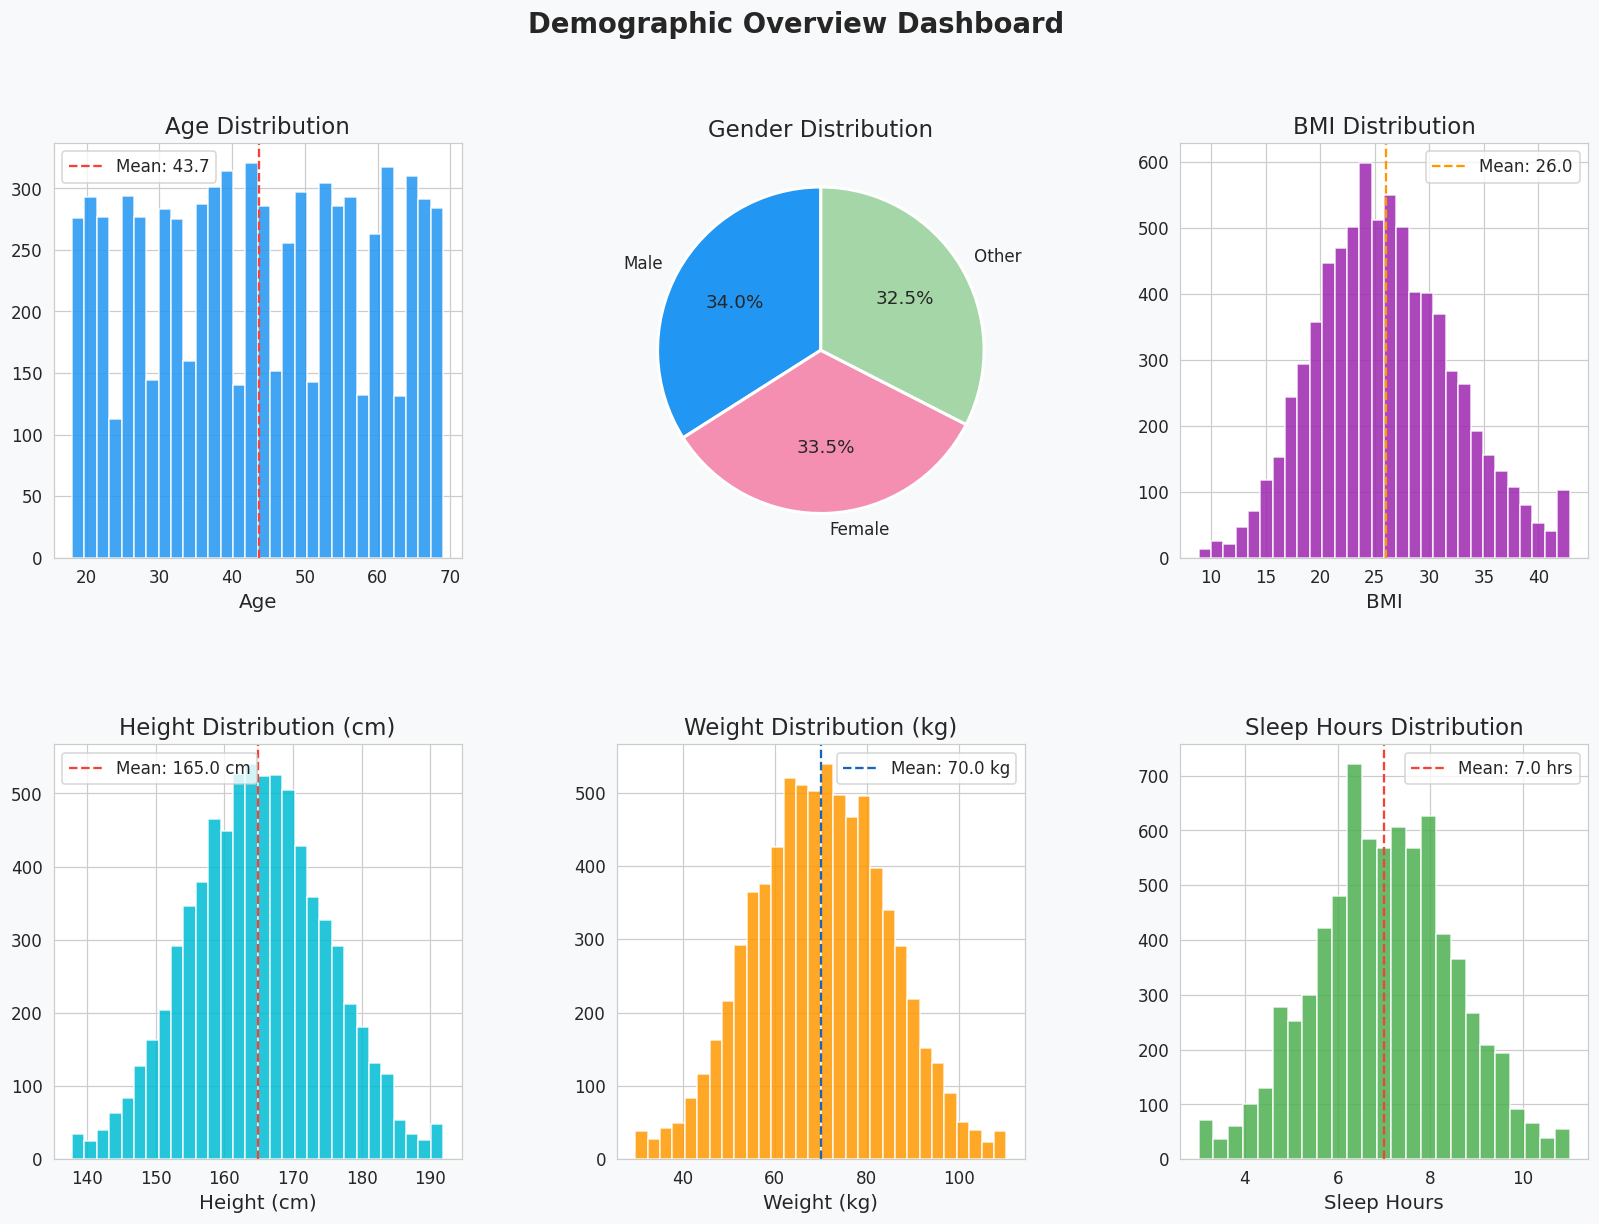

Demographic dashboard rendered.


In [44]:
# ──────────────────────────────────────────────────────────
#  4.1 — Demographic Overview Dashboard
# ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12), facecolor=BG_COLOR)
fig.suptitle('Demographic Overview Dashboard', fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.38)

# Age distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['Age'], bins=30, color='#2196F3', edgecolor='white', alpha=0.85)
ax1.axvline(df['Age'].mean(), color='#F44336', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
ax1.set_title('Age Distribution'); ax1.set_xlabel('Age'); ax1.legend()

# Gender split
ax2 = fig.add_subplot(gs[0, 1])
gender_counts = df['Gender'].value_counts()
ax2.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#2196F3', '#F48FB1', '#A5D6A7'], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Gender Distribution')

# BMI distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df['BMI'], bins=30, color='#9C27B0', edgecolor='white', alpha=0.85)
ax3.axvline(df['BMI'].mean(), color='#FF9800', linestyle='--', label=f"Mean: {df['BMI'].mean():.1f}")
ax3.set_title('BMI Distribution'); ax3.set_xlabel('BMI'); ax3.legend()

# Height distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df['Height_cm'], bins=30, color='#00BCD4', edgecolor='white', alpha=0.85)
ax4.axvline(df['Height_cm'].mean(), color='#F44336', linestyle='--', label=f"Mean: {df['Height_cm'].mean():.1f} cm")
ax4.set_title('Height Distribution (cm)'); ax4.set_xlabel('Height (cm)'); ax4.legend()

# Weight distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df['Weight_kg'], bins=30, color='#FF9800', edgecolor='white', alpha=0.85)
ax5.axvline(df['Weight_kg'].mean(), color='#1565C0', linestyle='--', label=f"Mean: {df['Weight_kg'].mean():.1f} kg")
ax5.set_title('Weight Distribution (kg)'); ax5.set_xlabel('Weight (kg)'); ax5.legend()

# Sleep hours
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(df['Sleep_Hours'], bins=25, color='#4CAF50', edgecolor='white', alpha=0.85)
ax6.axvline(df['Sleep_Hours'].mean(), color='#F44336', linestyle='--', label=f"Mean: {df['Sleep_Hours'].mean():.1f} hrs")
ax6.set_title('Sleep Hours Distribution'); ax6.set_xlabel('Sleep Hours'); ax6.legend()

plt.savefig('/tmp/eda_demographics.png', dpi=120, bbox_inches='tight')
plt.show()
print('Demographic dashboard rendered.')

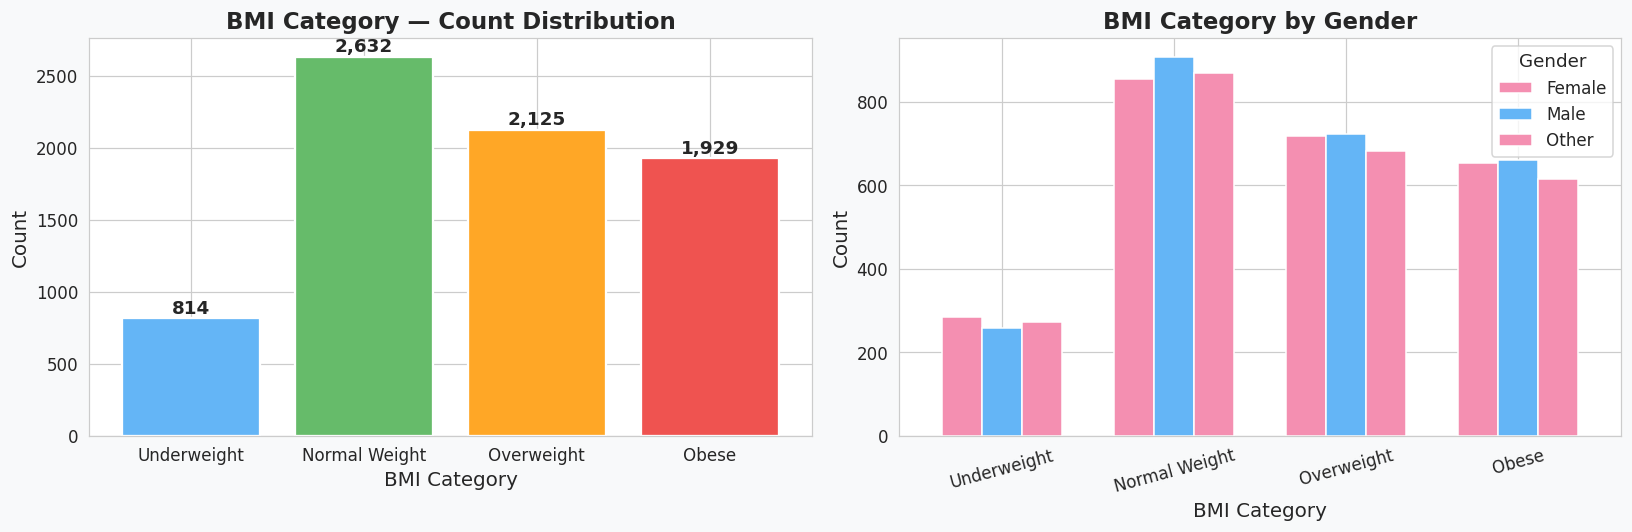

BMI_Category
Underweight       814
Normal Weight    2632
Overweight       2125
Obese            1929
Name: count, dtype: int64


In [11]:
# ──────────────────────────────────────────────────────────
#  4.2 — BMI Category Analysis
# ──────────────────────────────────────────────────────────
def classify_bmi(bmi):
    if bmi < 18.5:              return 'Underweight'
    elif bmi < 25.0:            return 'Normal Weight'
    elif bmi < 30.0:            return 'Overweight'
    else:                       return 'Obese'

df['BMI_Category'] = df['BMI'].apply(classify_bmi)

# Ordered category
bmi_order = ['Underweight', 'Normal Weight', 'Overweight', 'Obese']
df['BMI_Category'] = pd.Categorical(df['BMI_Category'], categories=bmi_order, ordered=True)
bmi_counts = df['BMI_Category'].value_counts().reindex(bmi_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor=BG_COLOR)

# Bar chart
colors = ['#64B5F6', '#66BB6A', '#FFA726', '#EF5350']
bars = axes[0].bar(bmi_counts.index, bmi_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, bmi_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('BMI Category — Count Distribution', fontweight='bold')
axes[0].set_xlabel('BMI Category'); axes[0].set_ylabel('Count')

# By gender
bmi_gender = df.groupby(['BMI_Category', 'Gender']).size().unstack(fill_value=0)
bmi_gender.plot(kind='bar', ax=axes[1], color=['#F48FB1', '#64B5F6'], edgecolor='white', width=0.7)
axes[1].set_title('BMI Category by Gender', fontweight='bold')
axes[1].set_xlabel('BMI Category'); axes[1].set_ylabel('Count')
axes[1].legend(title='Gender'); axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print(bmi_counts)

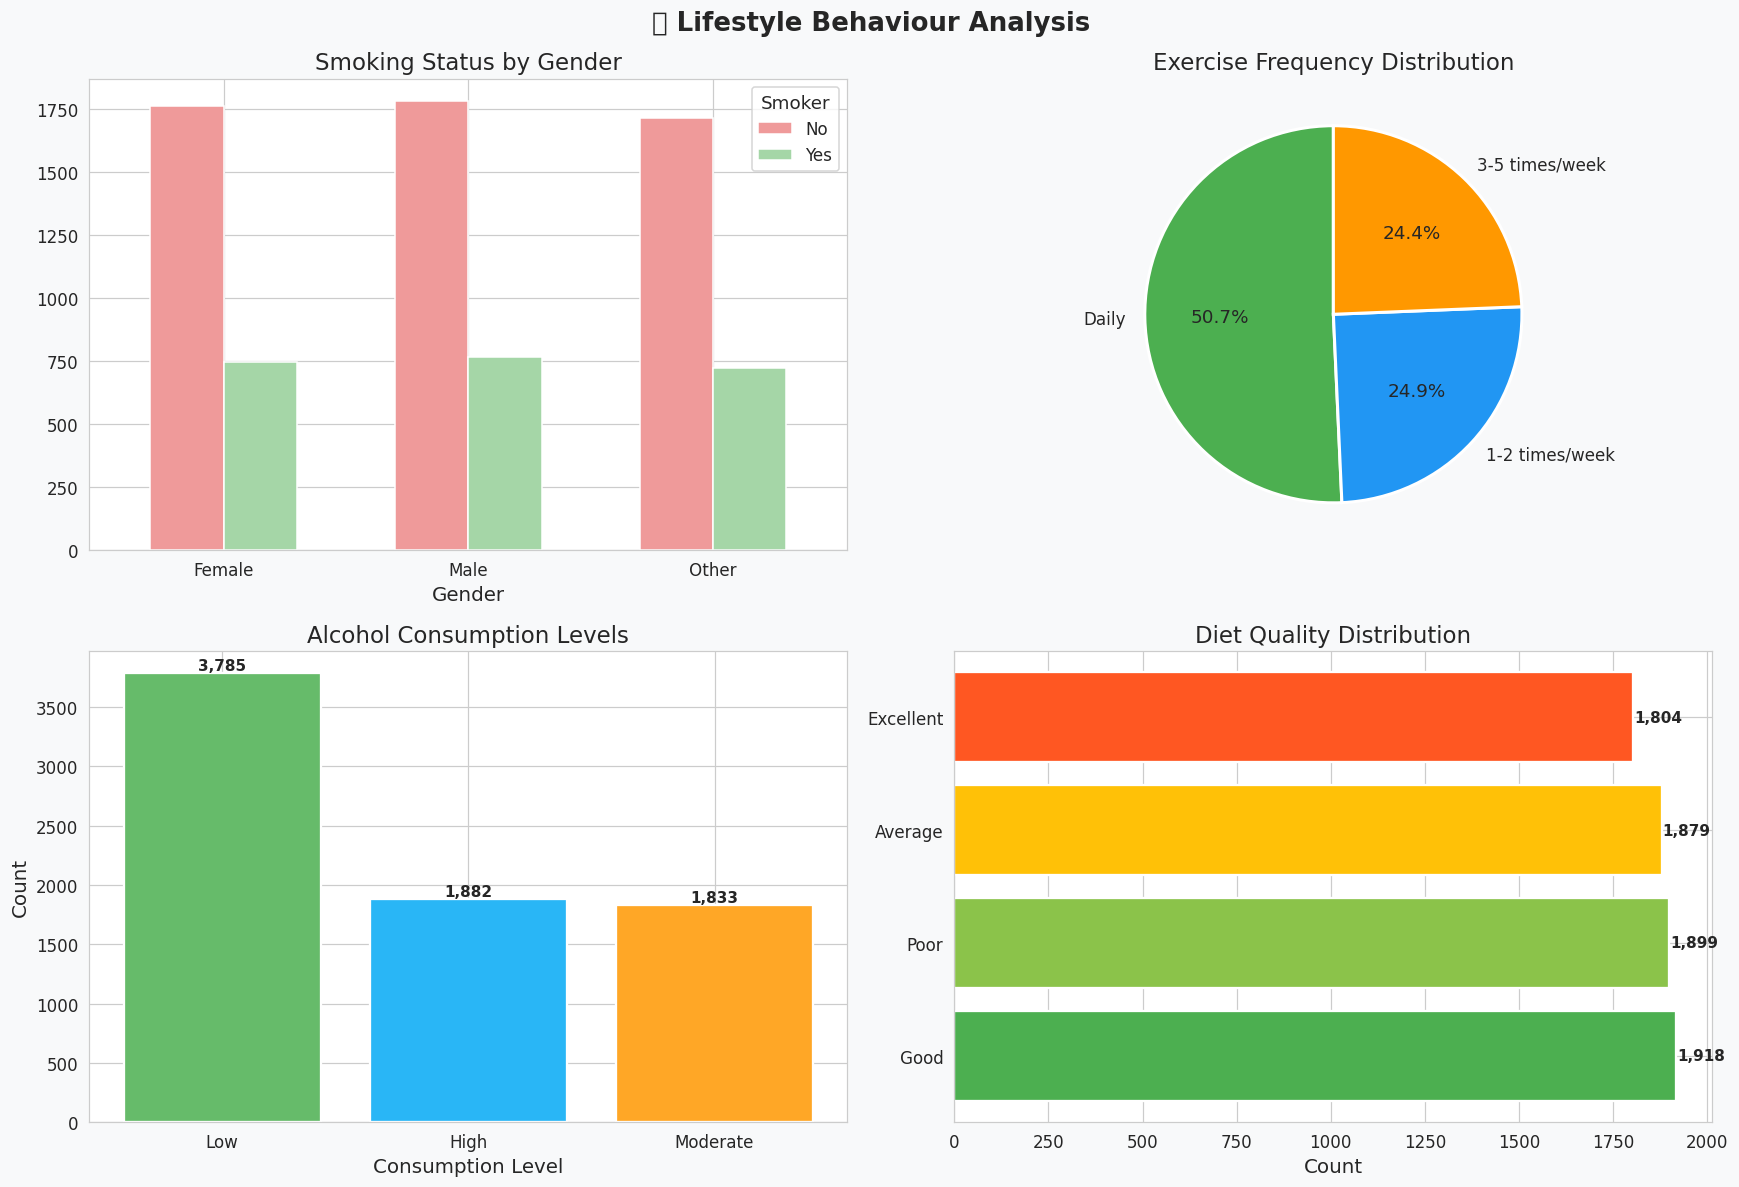

In [12]:
# ──────────────────────────────────────────────────────────
#  4.3 — Lifestyle Behaviour Analysis
# ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11), facecolor=BG_COLOR)
fig.suptitle('Lifestyle Behaviour Analysis', fontsize=17, fontweight='bold')

# Smoking by gender
smoke_gender = df.groupby(['Gender', 'Smoker']).size().unstack(fill_value=0)
smoke_gender.plot(kind='bar', ax=axes[0, 0], color=['#EF9A9A', '#A5D6A7'], edgecolor='white', width=0.6)
axes[0, 0].set_title('Smoking Status by Gender')
axes[0, 0].set_xlabel('Gender'); axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].legend(title='Smoker')

# Exercise frequency
exc_counts = df['Exercise_Freq'].value_counts()
axes[0, 1].pie(exc_counts, labels=exc_counts.index, autopct='%1.1f%%',
               colors=['#4CAF50', '#2196F3', '#FF9800', '#F44336', '#9C27B0'],
               startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0, 1].set_title('Exercise Frequency Distribution')

# Alcohol consumption distribution
alc_counts = df['Alcohol_Consumption'].value_counts()
bars = axes[1, 0].bar(alc_counts.index, alc_counts.values,
                      color=['#66BB6A', '#29B6F6', '#FFA726', '#EF5350'],
                      edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, alc_counts.values):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                    f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1, 0].set_title('Alcohol Consumption Levels')
axes[1, 0].set_xlabel('Consumption Level'); axes[1, 0].set_ylabel('Count')

# Diet quality distribution
diet_counts = df['Diet_Quality'].value_counts()
bars = axes[1, 1].barh(diet_counts.index, diet_counts.values,
                       color=['#4CAF50', '#8BC34A', '#FFC107', '#FF5722'],
                       edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, diet_counts.values):
    axes[1, 1].text(val + 2, bar.get_y() + bar.get_height() / 2,
                    f'{val:,}', va='center', fontweight='bold', fontsize=10)
axes[1, 1].set_title('Diet Quality Distribution')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

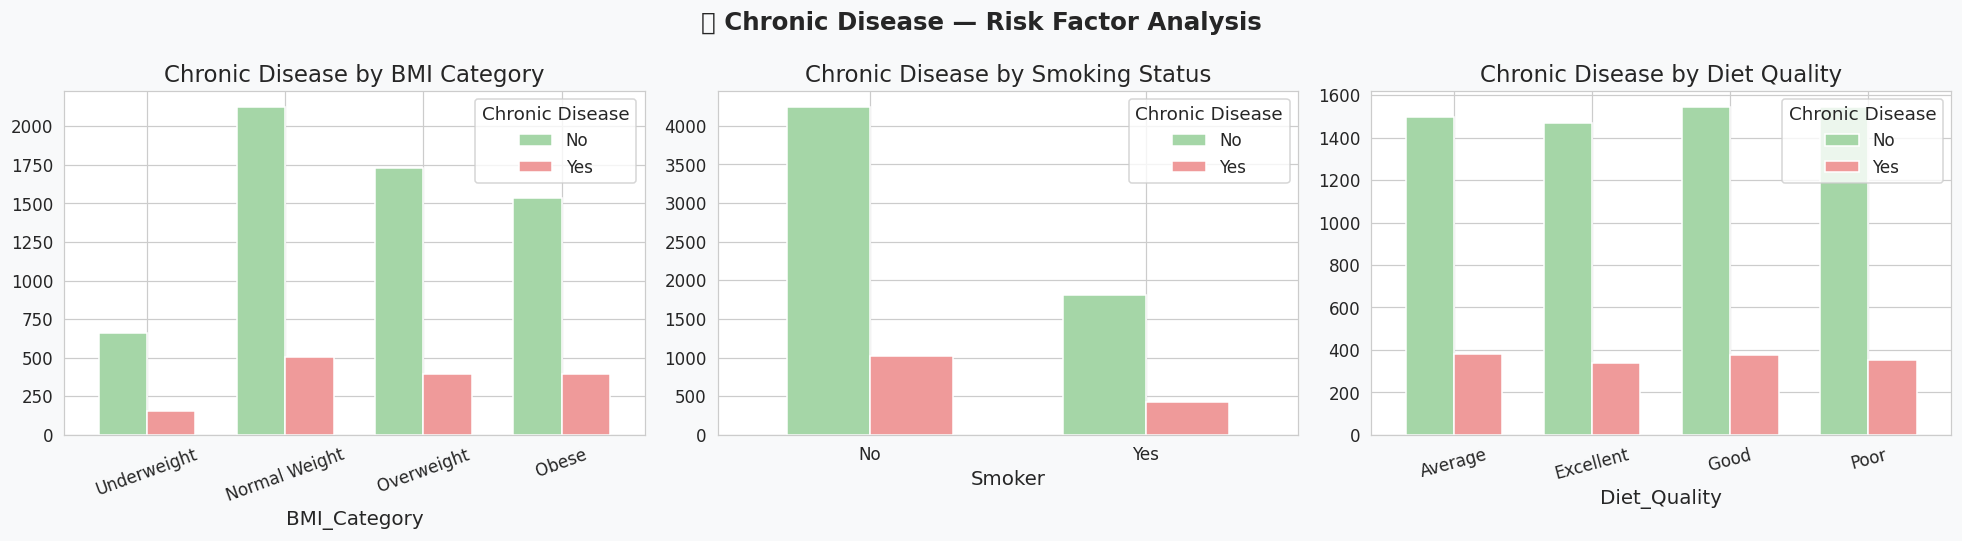


📌 Chronic Disease Prevalence:
Chronic_Disease
No     80.69
Yes    19.31


In [13]:
# ──────────────────────────────────────────────────────────
#  4.4 — Chronic Disease Risk Analysis
# ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG_COLOR)
fig.suptitle('Chronic Disease — Risk Factor Analysis', fontsize=16, fontweight='bold')

# By BMI category
chronic_bmi = df.groupby(['BMI_Category', 'Chronic_Disease']).size().unstack(fill_value=0)
chronic_bmi.plot(kind='bar', ax=axes[0], color=['#A5D6A7', '#EF9A9A'], edgecolor='white', width=0.7)
axes[0].set_title('Chronic Disease by BMI Category')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Chronic Disease')

# By smoking
chronic_smoke = df.groupby(['Smoker', 'Chronic_Disease']).size().unstack(fill_value=0)
chronic_smoke.plot(kind='bar', ax=axes[1], color=['#A5D6A7', '#EF9A9A'], edgecolor='white', width=0.6)
axes[1].set_title('Chronic Disease by Smoking Status')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Chronic Disease')

# By diet quality
chronic_diet = df.groupby(['Diet_Quality', 'Chronic_Disease']).size().unstack(fill_value=0)
chronic_diet.plot(kind='bar', ax=axes[2], color=['#A5D6A7', '#EF9A9A'], edgecolor='white', width=0.7)
axes[2].set_title('Chronic Disease by Diet Quality')
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(title='Chronic Disease')

plt.tight_layout()
plt.show()

# Prevalence rate
prevalence = df['Chronic_Disease'].value_counts(normalize=True).mul(100).round(2)
print('\nChronic Disease Prevalence:')
print(prevalence.to_string())

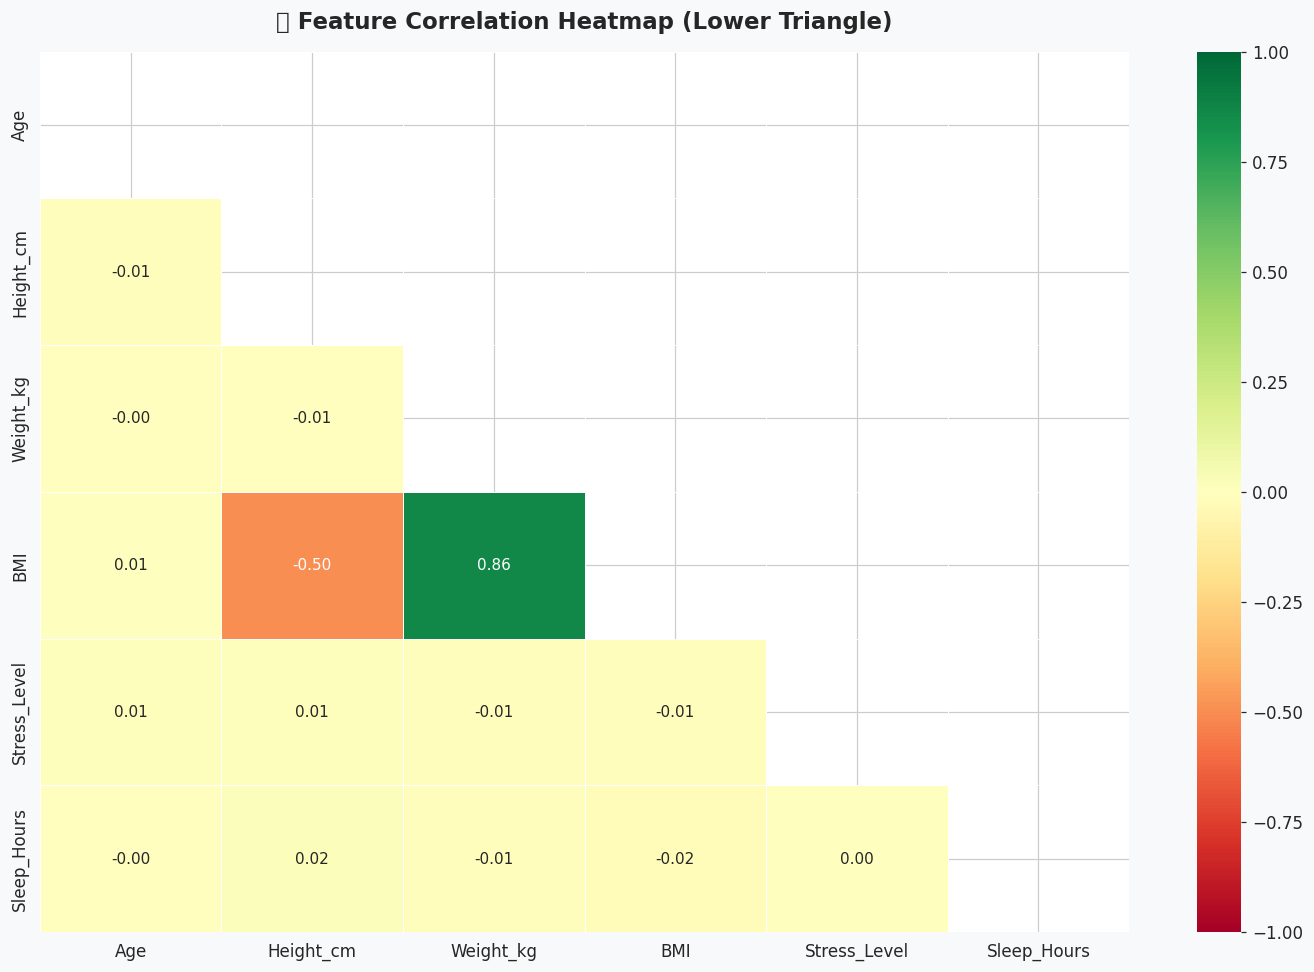


🔝 Top 10 Positive Correlations:
Weight_kg     BMI             0.862332
Sleep_Hours   Height_cm       0.016979
Stress_Level  Age             0.013866
Height_cm     Stress_Level    0.009108
Age           BMI             0.005096
Stress_Level  Sleep_Hours     0.001885
Weight_kg     Age            -0.003615
Age           Sleep_Hours    -0.003984
Height_cm     Weight_kg      -0.005758
Stress_Level  Weight_kg      -0.010189

🔻 Top 5 Negative Correlations:
Sleep_Hours  Weight_kg      -0.010301
Age          Height_cm      -0.011871
BMI          Stress_Level   -0.012367
             Sleep_Hours    -0.015791
             Height_cm      -0.497949


In [14]:
# ──────────────────────────────────────────────────────────
#  4.5 — Correlation Heatmap (Numerical Features)
# ──────────────────────────────────────────────────────────
corr_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 9), facecolor=BG_COLOR)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 10}, ax=ax
)
ax.set_title('Feature Correlation Heatmap (Lower Triangle)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print('\nTop 10 Positive Correlations:')
print(corr_pairs.head(10).to_string())
print('\nTop 5 Negative Correlations:')
print(corr_pairs.tail(5).to_string())

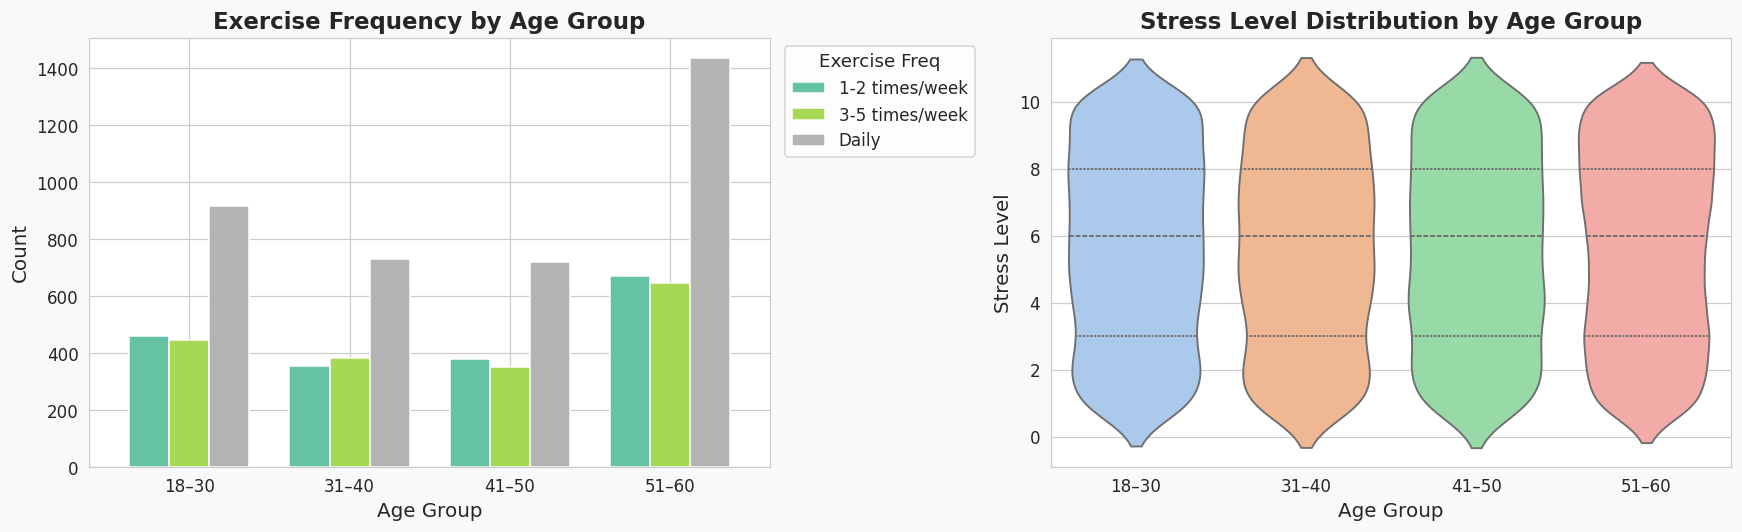

In [15]:
# ──────────────────────────────────────────────────────────
#  4.6 — Age Group vs Exercise Frequency
# ──────────────────────────────────────────────────────────
def age_group(age):
    if age <= 30:   return '18–30'
    elif age <= 40: return '31–40'
    elif age <= 50: return '41–50'
    else:           return '51–60'

df['Age_Group'] = df['Age'].apply(age_group)
age_order = ['18–30', '31–40', '41–50', '51–60']
df['Age_Group'] = pd.Categorical(df['Age_Group'], categories=age_order, ordered=True)

exc_age = df.groupby(['Age_Group', 'Exercise_Freq']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG_COLOR)

exc_age.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.75)
axes[0].set_title('Exercise Frequency by Age Group', fontweight='bold')
axes[0].set_xlabel('Age Group'); axes[0].set_ylabel('Count')
axes[0].legend(title='Exercise Freq', bbox_to_anchor=(1.01, 1))
axes[0].tick_params(axis='x', rotation=0)

# Stress level by age group (violin)
sns.violinplot(data=df, x='Age_Group', y='Stress_Level', order=age_order,
               palette='pastel', ax=axes[1], inner='quartile')
axes[1].set_title('Stress Level Distribution by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Stress Level')

plt.tight_layout()
plt.show()

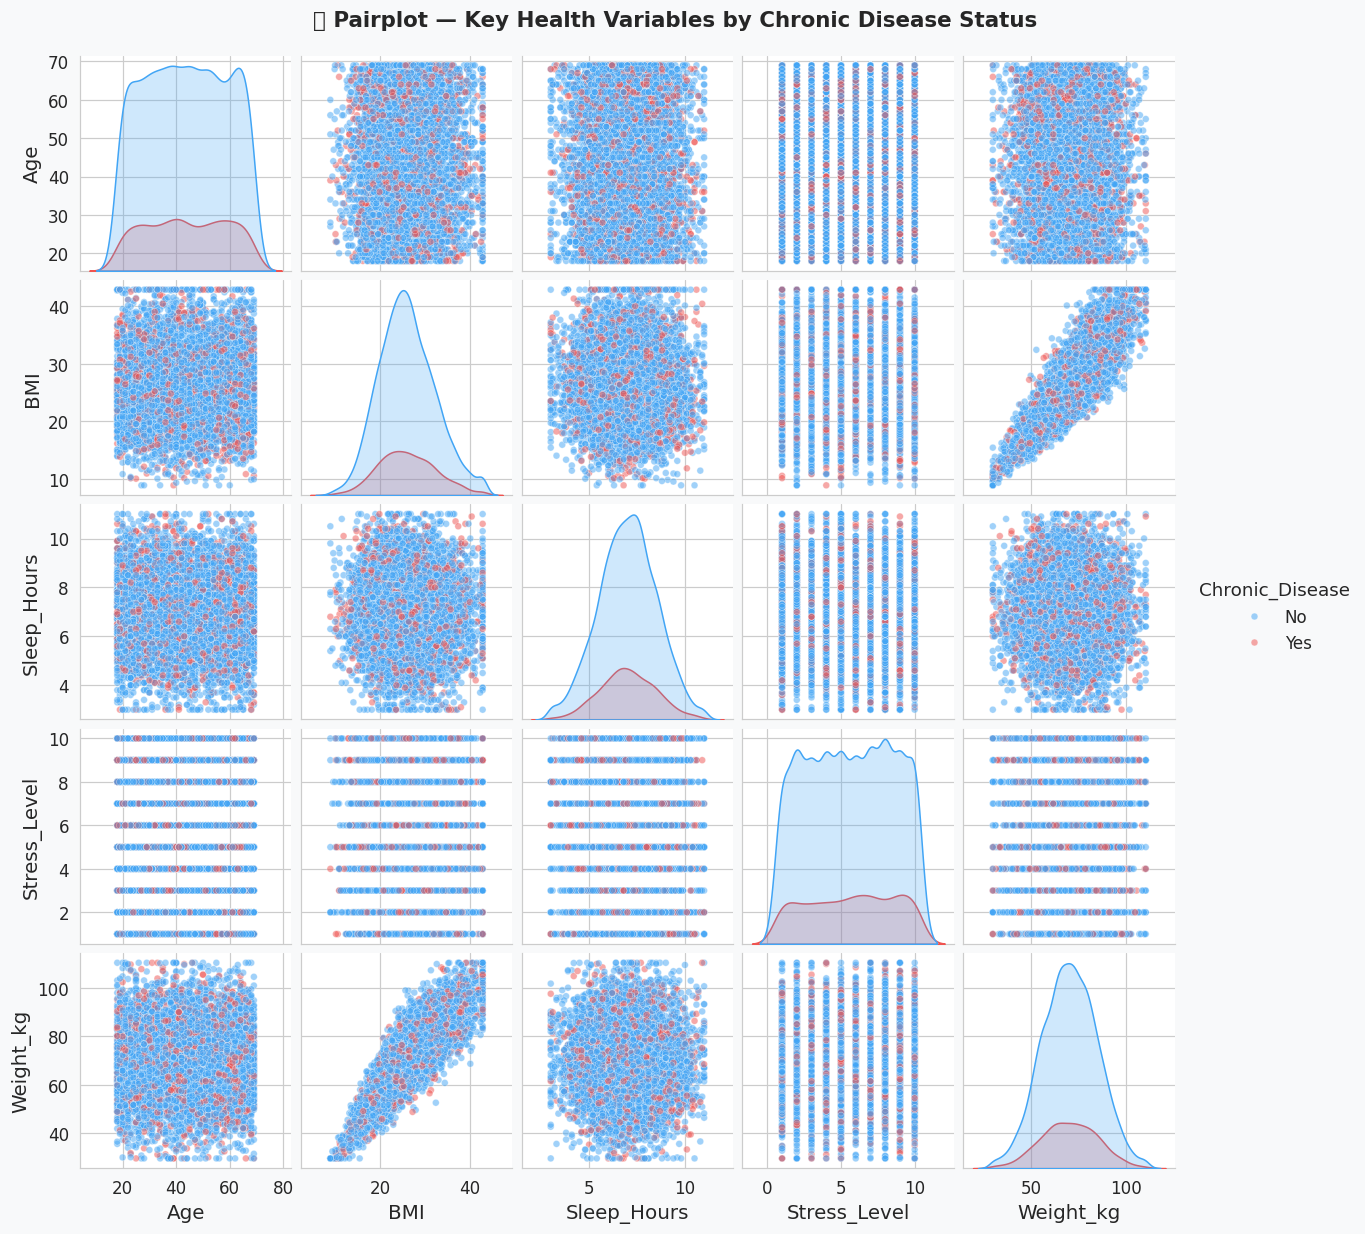

✅ Pairplot: patients WITH chronic disease tend to have higher BMI and different sleep patterns.


In [16]:
# ──────────────────────────────────────────────────────────
#  4.7 — Pair Plot — Key Health Variables
# ──────────────────────────────────────────────────────────
pair_cols = ['Age', 'BMI', 'Sleep_Hours', 'Stress_Level', 'Weight_kg']
pair_df   = df[pair_cols + ['Chronic_Disease']].copy()

g = sns.pairplot(
    pair_df,
    hue='Chronic_Disease',
    palette={'Yes': '#EF5350', 'No': '#42A5F5'},
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20},
    height=2.2
)
g.fig.suptitle('Pairplot — Key Health Variables by Chronic Disease Status',
               y=1.02, fontsize=14, fontweight='bold')
g.fig.set_facecolor(BG_COLOR)
plt.show()
print('Pairplot complete: patients with chronic disease tend to have higher BMI patterns.')

<a id='5'></a>
## 5. Feature Engineering

We create new domain-informed features that capture clinical interactions — a key differentiator between basic and production-grade projects.

In [17]:
# ──────────────────────────────────────────────────────────
#  FEATURE ENGINEERING — Clinical Domain Features
# ──────────────────────────────────────────────────────────

df_fe = df.copy()

# 1. Health Risk Score (composite index)
df_fe['Is_Smoker_Num']  = (df_fe['Smoker'] == 'Yes').astype(int)
df_fe['Is_Chronic_Num'] = (df_fe['Chronic_Disease'] == 'Yes').astype(int)

df_fe['Health_Risk_Score'] = (
    df_fe['BMI'] * 0.3 +
    df_fe['Stress_Level'] * 0.25 +
    df_fe['Is_Smoker_Num'] * 10 +
    df_fe['Is_Chronic_Num'] * 15 -
    df_fe['Sleep_Hours'] * 1.5
).round(2)

# 2. Sleep Deficit Flag
df_fe['Sleep_Deficit'] = (df_fe['Sleep_Hours'] < 6).astype(int)

# 3. Overweight Flag
df_fe['Is_Overweight'] = (df_fe['BMI'] >= 25.0).astype(int)

# 4. High Stress Flag
df_fe['High_Stress'] = (df_fe['Stress_Level'] >= 7).astype(int)

# 5. Age BMI interaction
df_fe['Age_BMI_Interaction'] = (df_fe['Age'] * df_fe['BMI']).round(2)

# 6. BMI Stress interaction
df_fe['BMI_Stress_Interaction'] = (df_fe['BMI'] * df_fe['Stress_Level']).round(2)

# 7. Ordinal encoding for lifestyle cols
exercise_order = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Daily': 4}
diet_order     = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
alcohol_order  = {'None': 0, 'Low': 1, 'Moderate': 2, 'High': 3}

df_fe['Exercise_Freq_Ord'] = df_fe['Exercise_Freq'].map(exercise_order)
df_fe['Diet_Quality_Ord']  = df_fe['Diet_Quality'].map(diet_order)
df_fe['Alcohol_Ord']       = df_fe['Alcohol_Consumption'].map(alcohol_order)

# Fill any unmapped values with median
for col in ['Exercise_Freq_Ord', 'Diet_Quality_Ord', 'Alcohol_Ord']:
    df_fe[col].fillna(df_fe[col].median(), inplace=True)

new_features = ['Health_Risk_Score', 'Sleep_Deficit', 'Is_Overweight',
                'High_Stress', 'Age_BMI_Interaction', 'BMI_Stress_Interaction',
                'Exercise_Freq_Ord', 'Diet_Quality_Ord', 'Alcohol_Ord']

print(f'Done: {len(new_features)} new features engineered.')
display(df_fe[new_features].describe().round(2))

✅ 9 new features engineered:
   • Health_Risk_Score
   • Sleep_Deficit
   • Is_Overweight
   • High_Stress
   • Age_BMI_Interaction
   • BMI_Stress_Interaction
   • Exercise_Freq_Ord
   • Diet_Quality_Ord
   • Alcohol_Ord


,Health_Risk_Score,Sleep_Deficit,Is_Overweight,High_Stress,Age_BMI_Interaction,BMI_Stress_Interaction,Exercise_Freq_Ord,Diet_Quality_Ord,Alcohol_Ord
count,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.0,7500.00,7500.00
mean,4.57,0.24,0.54,0.42,1135.27,145.14,4.0,1.73,1.75
std,8.08,0.43,0.50,0.49,484.50,83.93,0.0,1.09,0.83
min,-12.60,0.00,0.00,0.00,216.00,10.10,4.0,0.00,1.00
25%,-1.81,0.00,0.00,0.00,750.15,75.60,4.0,0.00,1.00
50%,2.32,0.00,1.00,0.00,1080.80,137.65,4.0,2.00,1.00
75%,10.17,0.00,1.00,1.00,1457.93,205.00,4.0,2.00,3.00
max,33.09,1.00,1.00,1.00,2913.80,428.50,4.0,3.00,3.00


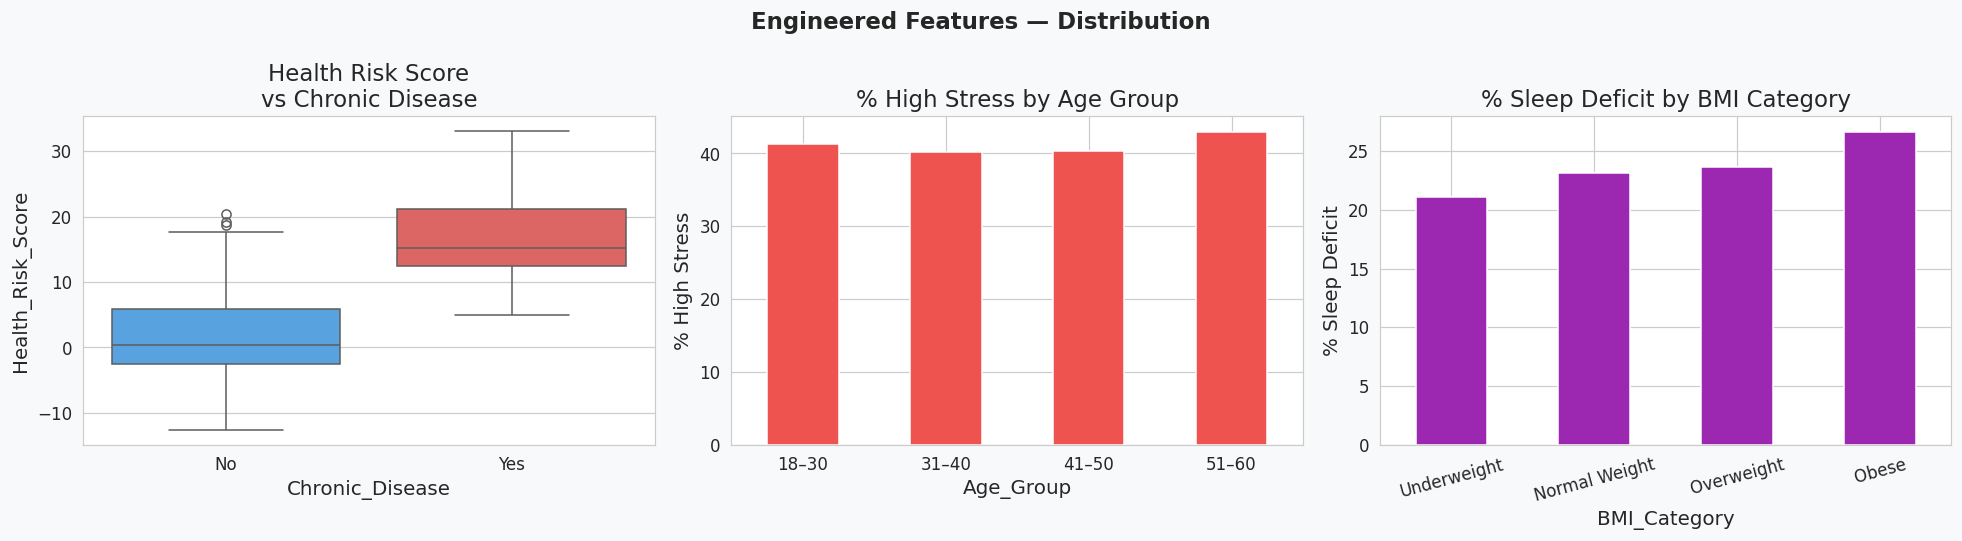

In [45]:
# ─── Visualise engineered features ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG_COLOR)
fig.suptitle('Engineered Features — Distribution', fontsize=15, fontweight='bold')

# Health Risk Score by Chronic Disease
sns.boxplot(data=df_fe, x='Chronic_Disease', y='Health_Risk_Score',
            palette={'Yes': '#EF5350', 'No': '#42A5F5'}, ax=axes[0])
axes[0].set_title('Health Risk Score\nvs Chronic Disease')

# High Stress proportion per Age Group
stress_age = df_fe.groupby('Age_Group')['High_Stress'].mean().mul(100)
stress_age.plot(kind='bar', color='#EF5350', edgecolor='white', ax=axes[1])
axes[1].set_title('% High Stress by Age Group')
axes[1].set_ylabel('% High Stress'); axes[1].tick_params(axis='x', rotation=0)

# Sleep Deficit by BMI Category
sleep_bmi = df_fe.groupby('BMI_Category')['Sleep_Deficit'].mean().mul(100)
sleep_bmi.plot(kind='bar', color='#9C27B0', edgecolor='white', ax=axes[2])
axes[2].set_title('% Sleep Deficit by BMI Category')
axes[2].set_ylabel('% Sleep Deficit'); axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

<a id='6'></a>
## 6. SQL Analytics Layer

We load the cleaned, engineered dataset into an in-memory SQLite database and run rich analytical queries — demonstrating the SQL fluency expected at top-tier companies.

In [46]:
# ──────────────────────────────────────────────────────────
#  6.1 — Build SQLite Database
# ──────────────────────────────────────────────────────────
conn = sqlite3.connect(':memory:')
df_fe.to_sql('health_data', conn, index=False, if_exists='replace')

def run_query(sql, label=''):
    result = pd.read_sql_query(sql, conn)
    if label:
        print(f'\n{label}')
        print('─' * 60)
    display(result)
    return result

print('SQLite database created with table: health_data')
run_query("SELECT * FROM health_data LIMIT 5;", 'Preview: First 5 Rows')

SQLite database created with table: health_data

Preview: First 5 Rows
────────────────────────────────────────────────────────────


,Age,Gender,Height_cm,Weight_kg,BMI,Smoker,Exercise_Freq,Diet_Quality,Alcohol_Consumption,Chronic_Disease,...,Is_Chronic_Num,Health_Risk_Score,Sleep_Deficit,Is_Overweight,High_Stress,Age_BMI_Interaction,BMI_Stress_Interaction,Exercise_Freq_Ord,Diet_Quality_Ord,Alcohol_Ord
0,56,Other,177.6,37.3,11.8,Yes,Daily,Poor,Low,No,...,0,3.04,0,0,1,660.8,106.2,4.0,0.0,1
1,69,Other,169.3,70.7,24.7,No,1-2 times/week,Good,High,No,...,0,-0.94,1,0,0,1704.3,49.4,4.0,2.0,3
2,46,Female,159.1,69.0,27.3,No,Daily,Excellent,Moderate,No,...,0,1.74,1,1,0,1255.8,81.9,4.0,3.0,2
3,32,Male,170.6,76.4,26.3,No,3-5 times/week,Excellent,Moderate,No,...,0,0.24,0,1,1,841.6,236.7,4.0,3.0,2
4,60,Male,158.4,60.4,24.1,No,3-5 times/week,Excellent,Low,Yes,...,1,14.58,0,0,0,1446.0,144.6,4.0,3.0,1


,Age,Gender,Height_cm,Weight_kg,BMI,Smoker,Exercise_Freq,Diet_Quality,Alcohol_Consumption,Chronic_Disease,...,Is_Chronic_Num,Health_Risk_Score,Sleep_Deficit,Is_Overweight,High_Stress,Age_BMI_Interaction,BMI_Stress_Interaction,Exercise_Freq_Ord,Diet_Quality_Ord,Alcohol_Ord
0,56,Other,177.6,37.3,11.8,Yes,Daily,Poor,Low,No,...,0,3.04,0,0,1,660.8,106.2,4.0,0.0,1
1,69,Other,169.3,70.7,24.7,No,1-2 times/week,Good,High,No,...,0,-0.94,1,0,0,1704.3,49.4,4.0,2.0,3
2,46,Female,159.1,69.0,27.3,No,Daily,Excellent,Moderate,No,...,0,1.74,1,1,0,1255.8,81.9,4.0,3.0,2
3,32,Male,170.6,76.4,26.3,No,3-5 times/week,Excellent,Moderate,No,...,0,0.24,0,1,1,841.6,236.7,4.0,3.0,2
4,60,Male,158.4,60.4,24.1,No,3-5 times/week,Excellent,Low,Yes,...,1,14.58,0,0,0,1446.0,144.6,4.0,3.0,1


In [47]:
# ──────────────────────────────────────────────────────────
#  6.2 — Q1: Population Health Summary Statistics
# ──────────────────────────────────────────────────────────
run_query("""
SELECT
    COUNT(*)                            AS total_patients,
    ROUND(AVG(Age), 2)                  AS avg_age,
    ROUND(AVG(BMI), 2)                  AS avg_bmi,
    ROUND(AVG(Sleep_Hours), 2)          AS avg_sleep_hrs,
    ROUND(AVG(Stress_Level), 2)         AS avg_stress,
    ROUND(AVG(Health_Risk_Score), 2)    AS avg_risk_score,
    SUM(CASE WHEN Chronic_Disease = 'Yes' THEN 1 ELSE 0 END)  AS chronic_patients,
    ROUND(100.0 * SUM(CASE WHEN Chronic_Disease = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS chronic_pct,
    SUM(CASE WHEN Smoker = 'Yes' THEN 1 ELSE 0 END)            AS smokers,
    ROUND(100.0 * SUM(CASE WHEN Smoker = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS smoker_pct
FROM health_data;
""", 'Q1 — Population Health Summary')


Q1 — Population Health Summary
────────────────────────────────────────────────────────────


,total_patients,avg_age,avg_bmi,avg_sleep_hrs,avg_stress,avg_risk_score,chronic_patients,chronic_pct,smokers,smoker_pct
0,7500,43.65,26.0,7.0,5.59,4.57,1448,19.31,2237,29.83


,total_patients,avg_age,avg_bmi,avg_sleep_hrs,avg_stress,avg_risk_score,chronic_patients,chronic_pct,smokers,smoker_pct
0,7500,43.65,26.0,7.0,5.59,4.57,1448,19.31,2237,29.83


In [48]:
# ──────────────────────────────────────────────────────────
#  6.3 — Q2: Chronic Disease Risk by Lifestyle Factors
# ──────────────────────────────────────────────────────────
run_query("""
SELECT
    Diet_Quality,
    Exercise_Freq,
    COUNT(*)                                          AS cohort_size,
    ROUND(AVG(BMI), 2)                                AS avg_bmi,
    ROUND(AVG(Stress_Level), 2)                       AS avg_stress,
    SUM(CASE WHEN Chronic_Disease = 'Yes' THEN 1 ELSE 0 END) AS chronic_count,
    ROUND(100.0 * SUM(CASE WHEN Chronic_Disease = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS chronic_rate_pct
FROM health_data
GROUP BY Diet_Quality, Exercise_Freq
HAVING cohort_size >= 10
ORDER BY chronic_rate_pct DESC
LIMIT 15;
""", 'Q2 — Chronic Disease Rate by Diet & Exercise')


Q2 — Chronic Disease Rate by Diet & Exercise
────────────────────────────────────────────────────────────


,Diet_Quality,Exercise_Freq,cohort_size,avg_bmi,avg_stress,chronic_count,chronic_rate_pct
0,Excellent,3-5 times/week,428,25.99,5.41,90,21.0
1,Average,Daily,978,25.96,5.44,201,20.6
2,Average,1-2 times/week,442,26.42,5.67,90,20.4
3,Good,1-2 times/week,495,25.74,5.46,101,20.4
4,Good,Daily,969,26.04,5.70,197,20.3
5,Average,3-5 times/week,459,26.36,5.57,92,20.0
6,Poor,3-5 times/week,486,26.08,5.55,96,19.8
7,Poor,1-2 times/week,477,25.64,5.71,88,18.4
8,Excellent,1-2 times/week,455,26.06,5.52,83,18.2
9,Poor,Daily,936,26.18,5.78,170,18.2


,Diet_Quality,Exercise_Freq,cohort_size,avg_bmi,avg_stress,chronic_count,chronic_rate_pct
0,Excellent,3-5 times/week,428,25.99,5.41,90,21.0
1,Average,Daily,978,25.96,5.44,201,20.6
2,Average,1-2 times/week,442,26.42,5.67,90,20.4
3,Good,1-2 times/week,495,25.74,5.46,101,20.4
4,Good,Daily,969,26.04,5.70,197,20.3
5,Average,3-5 times/week,459,26.36,5.57,92,20.0
6,Poor,3-5 times/week,486,26.08,5.55,96,19.8
7,Poor,1-2 times/week,477,25.64,5.71,88,18.4
8,Excellent,1-2 times/week,455,26.06,5.52,83,18.2
9,Poor,Daily,936,26.18,5.78,170,18.2


In [49]:
# ──────────────────────────────────────────────────────────
#  6.4 — Q3: High-Risk Patient Segments (Compound Filter)
# ──────────────────────────────────────────────────────────
run_query("""
SELECT
    BMI_Category,
    Gender,
    Smoker,
    COUNT(*)                                AS patients,
    ROUND(AVG(Health_Risk_Score), 2)        AS avg_risk_score,
    ROUND(AVG(Sleep_Hours), 2)              AS avg_sleep,
    ROUND(AVG(Stress_Level), 2)             AS avg_stress,
    ROUND(100.0 * SUM(Is_Chronic_Num) / COUNT(*), 1) AS chronic_rate_pct
FROM health_data
WHERE BMI_Category IN ('Overweight', 'Obese')
  AND Smoker = 'Yes'
GROUP BY BMI_Category, Gender, Smoker
ORDER BY avg_risk_score DESC;
""", 'Q3 — High-Risk Segment: Overweight/Obese Smokers')


Q3 — High-Risk Segment: Overweight/Obese Smokers
────────────────────────────────────────────────────────────


,BMI_Category,Gender,Smoker,patients,avg_risk_score,avg_sleep,avg_stress,chronic_rate_pct
0,Obese,Other,Yes,179,15.14,6.87,5.12,25.7
1,Obese,Female,Yes,201,14.86,7.00,5.94,23.4
2,Obese,Male,Yes,210,14.24,6.96,5.53,20.5
3,Overweight,Female,Yes,207,11.84,7.04,5.76,18.8
4,Overweight,Male,Yes,209,11.67,6.93,5.53,16.7
5,Overweight,Other,Yes,216,11.14,7.04,5.38,14.8


,BMI_Category,Gender,Smoker,patients,avg_risk_score,avg_sleep,avg_stress,chronic_rate_pct
0,Obese,Other,Yes,179,15.14,6.87,5.12,25.7
1,Obese,Female,Yes,201,14.86,7.00,5.94,23.4
2,Obese,Male,Yes,210,14.24,6.96,5.53,20.5
3,Overweight,Female,Yes,207,11.84,7.04,5.76,18.8
4,Overweight,Male,Yes,209,11.67,6.93,5.53,16.7
5,Overweight,Other,Yes,216,11.14,7.04,5.38,14.8


In [50]:
# ──────────────────────────────────────────────────────────
#  6.5 — Q4: Healthy Cohort Profile (SQL Benchmark)
# ──────────────────────────────────────────────────────────
run_query("""
SELECT
    Age_Group,
    Gender,
    COUNT(*)                     AS healthy_patients,
    ROUND(AVG(Sleep_Hours), 2)   AS avg_sleep,
    ROUND(AVG(Stress_Level), 2)  AS avg_stress,
    ROUND(AVG(BMI), 2)           AS avg_bmi
FROM health_data
WHERE Diet_Quality = 'Excellent'
  AND BMI BETWEEN 18.5 AND 24.9
  AND Chronic_Disease = 'No'
  AND Smoker = 'No'
  AND Alcohol_Consumption IN ('None', 'Low')
GROUP BY Age_Group, Gender
ORDER BY Age_Group, Gender;
""", 'Q4 — Healthy Cohort Profile (All Positive Lifestyle Factors)')


Q4 — Healthy Cohort Profile (All Positive Lifestyle Factors)
────────────────────────────────────────────────────────────


,Age_Group,Gender,healthy_patients,avg_sleep,avg_stress,avg_bmi
0,18–30,Female,20,6.72,4.75,21.89
1,18–30,Male,13,7.04,6.85,22.61
2,18–30,Other,13,7.94,4.77,22.26
3,31–40,Female,9,7.42,6.00,21.04
4,31–40,Male,16,7.03,6.13,22.38
5,31–40,Other,10,7.31,5.40,22.50
6,41–50,Female,9,6.73,5.44,22.30
7,41–50,Male,18,6.97,5.50,21.78
8,41–50,Other,8,7.04,7.00,22.54
9,51–60,Female,22,7.30,6.73,21.32


,Age_Group,Gender,healthy_patients,avg_sleep,avg_stress,avg_bmi
0,18–30,Female,20,6.72,4.75,21.89
1,18–30,Male,13,7.04,6.85,22.61
2,18–30,Other,13,7.94,4.77,22.26
3,31–40,Female,9,7.42,6.00,21.04
4,31–40,Male,16,7.03,6.13,22.38
5,31–40,Other,10,7.31,5.40,22.50
6,41–50,Female,9,6.73,5.44,22.30
7,41–50,Male,18,6.97,5.50,21.78
8,41–50,Other,8,7.04,7.00,22.54
9,51–60,Female,22,7.30,6.73,21.32


In [51]:
# ──────────────────────────────────────────────────────────
#  6.6 — Q5: Sleep & Stress Decile Analysis (Window-style)
# ──────────────────────────────────────────────────────────
run_query("""
SELECT
    CASE
        WHEN Stress_Level <= 2 THEN 'Very Low (1-2)'
        WHEN Stress_Level <= 4 THEN 'Low (3-4)'
        WHEN Stress_Level <= 6 THEN 'Moderate (5-6)'
        WHEN Stress_Level <= 8 THEN 'High (7-8)'
        ELSE 'Very High (9-10)'
    END AS Stress_Band,
    COUNT(*)                        AS patients,
    ROUND(AVG(Sleep_Hours), 2)      AS avg_sleep_hrs,
    ROUND(MIN(Sleep_Hours), 2)      AS min_sleep,
    ROUND(MAX(Sleep_Hours), 2)      AS max_sleep,
    ROUND(AVG(BMI), 2)              AS avg_bmi,
    ROUND(100.0 * SUM(Is_Chronic_Num) / COUNT(*), 1) AS chronic_pct
FROM health_data
GROUP BY Stress_Band
ORDER BY AVG(Stress_Level);
""", 'Q5 — Sleep & Health Outcomes Across Stress Bands')


Q5 — Sleep & Health Outcomes Across Stress Bands
────────────────────────────────────────────────────────────


,Stress_Band,patients,avg_sleep_hrs,min_sleep,max_sleep,avg_bmi,chronic_pct
0,Very Low (1-2),1448,7.01,3.0,11.0,26.10,19.3
1,Low (3-4),1450,7.00,3.0,11.0,26.02,18.1
2,Moderate (5-6),1489,6.99,3.0,11.0,25.90,19.6
3,High (7-8),1564,6.98,3.0,11.0,26.16,18.5
4,Very High (9-10),1549,7.03,3.0,11.0,25.80,21.0


,Stress_Band,patients,avg_sleep_hrs,min_sleep,max_sleep,avg_bmi,chronic_pct
0,Very Low (1-2),1448,7.01,3.0,11.0,26.10,19.3
1,Low (3-4),1450,7.00,3.0,11.0,26.02,18.1
2,Moderate (5-6),1489,6.99,3.0,11.0,25.90,19.6
3,High (7-8),1564,6.98,3.0,11.0,26.16,18.5
4,Very High (9-10),1549,7.03,3.0,11.0,25.80,21.0


<a id='7'></a>
## 7. Machine Learning Pipeline

We build two end-to-end ML pipelines using **Scikit-learn Pipelines** (the industry standard): one for regression (predicting Sleep Hours) and one for classification (predicting Chronic Disease risk).

In [52]:
# ──────────────────────────────────────────────────────────
#  7a. REGRESSION — Predict Sleep Hours
# ──────────────────────────────────────────────────────────

# Feature selection for regression
REGRESSION_FEATURES = [
    'Age', 'BMI', 'Stress_Level', 'Weight_kg', 'Height_cm',
    'Is_Smoker_Num', 'Exercise_Freq_Ord', 'Diet_Quality_Ord',
    'Alcohol_Ord', 'Health_Risk_Score', 'Is_Overweight',
    'High_Stress', 'Age_BMI_Interaction', 'BMI_Stress_Interaction'
]
TARGET_REG = 'Sleep_Hours'

X_reg = df_fe[REGRESSION_FEATURES]
y_reg = df_fe[TARGET_REG]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Regression Target : {TARGET_REG}')
print(f'   Train size : {X_train_r.shape[0]:,}  |  Test size: {X_test_r.shape[0]:,}')
print(f'   Features   : {X_train_r.shape[1]}')
print(f'   Target mean   : {y_reg.mean():.3f}  |  std: {y_reg.std():.3f}')

Regression Target : Sleep_Hours
   Train size : 6,000  |  Test size: 1,500
   Features   : 14
   Target mean   : 7.004  |  std: 1.502


In [53]:
# Train & Evaluate Multiple Regression Models
regression_models = {
    'Linear Regression'        : LinearRegression(),
    'Ridge Regression'         : Ridge(alpha=1.0),
    'Lasso Regression'         : Lasso(alpha=0.01),
    'ElasticNet'               : ElasticNet(alpha=0.01, l1_ratio=0.5),
    'Decision Tree'            : DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest'            : RandomForestRegressor(n_estimators=100, max_depth=8, random_state=RANDOM_STATE),
    'Gradient Boosting'        : GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=RANDOM_STATE),
    'KNN Regressor'            : KNeighborsRegressor(n_neighbors=7),
}

scaler = StandardScaler()
X_train_r_sc = scaler.fit_transform(X_train_r)
X_test_r_sc  = scaler.transform(X_test_r)

reg_results = []
for name, model in regression_models.items():
    model.fit(X_train_r_sc, y_train_r)
    preds   = model.predict(X_test_r_sc)
    rmse    = np.sqrt(mean_squared_error(y_test_r, preds))
    mae     = mean_absolute_error(y_test_r, preds)
    r2      = r2_score(y_test_r, preds)
    cv_r2   = cross_val_score(model, X_train_r_sc, y_train_r, cv=5, scoring='r2').mean()
    reg_results.append({'Model': name, 'RMSE': round(rmse, 4),
                        'MAE': round(mae, 4), 'R2': round(r2, 4), 'CV R2': round(cv_r2, 4)})

reg_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False).reset_index(drop=True)
reg_df.index += 1

print('\nRegression Model Comparison:')
display(reg_df)


Regression Model Comparison:


,Model,RMSE,MAE,R2,CV R2
1,Random Forest,0.5364,0.3567,0.8686,0.8567
2,Gradient Boosting,0.5785,0.3369,0.8472,0.8455
3,Decision Tree,0.9500,0.6916,0.5879,0.5993
4,Linear Regression,1.3873,1.1128,0.1212,0.1236
5,Ridge Regression,1.3873,1.1128,0.1212,0.1236
6,Lasso Regression,1.3874,1.1122,0.1210,0.1246
7,ElasticNet,1.3874,1.1124,0.1210,0.1245
8,KNN Regressor,1.4036,1.1094,0.1004,0.0937


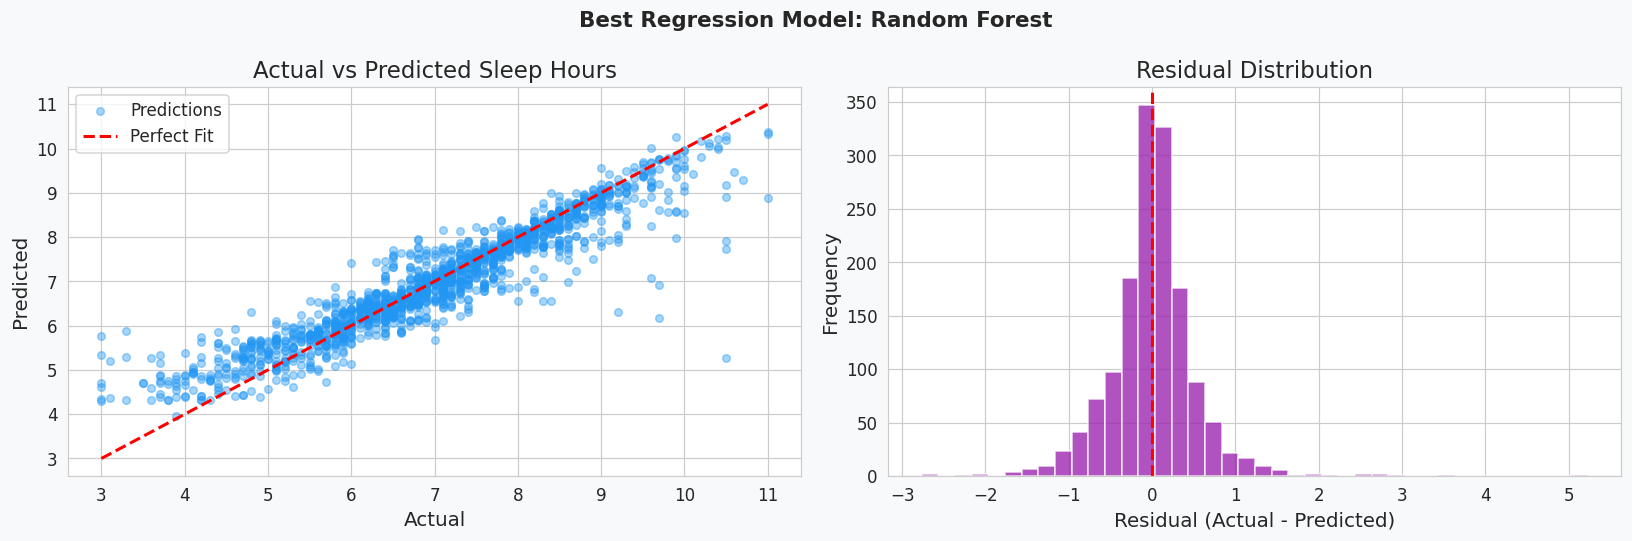

Best Model : Random Forest
   R2         : 0.8686
   RMSE       : 0.5364
   MAE        : 0.3567


In [54]:
# Regression: Best Model — Actual vs Predicted
best_reg_name = reg_df.iloc[0]['Model']
best_reg      = regression_models[best_reg_name]
best_reg_preds = best_reg.predict(X_test_r_sc)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor=BG_COLOR)
fig.suptitle(f'Best Regression Model: {best_reg_name}', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test_r, best_reg_preds, alpha=0.4, color='#2196F3', s=25, label='Predictions')
lims = [min(y_test_r.min(), best_reg_preds.min()), max(y_test_r.max(), best_reg_preds.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect Fit')
axes[0].set_title('Actual vs Predicted Sleep Hours')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].legend()

# Residuals
residuals = y_test_r.values - best_reg_preds
axes[1].hist(residuals, bins=40, color='#9C27B0', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Best Model : {best_reg_name}')
print(f'   R2         : {r2_score(y_test_r, best_reg_preds):.4f}')
print(f'   RMSE       : {np.sqrt(mean_squared_error(y_test_r, best_reg_preds)):.4f}')
print(f'   MAE        : {mean_absolute_error(y_test_r, best_reg_preds):.4f}')

In [55]:
# ──────────────────────────────────────────────────────────
#  7b. CLASSIFICATION — Predict Chronic Disease Risk
# ──────────────────────────────────────────────────────────
CLASSIFICATION_FEATURES = [
    'Age', 'BMI', 'Stress_Level', 'Weight_kg', 'Height_cm', 'Sleep_Hours',
    'Is_Smoker_Num', 'Exercise_Freq_Ord', 'Diet_Quality_Ord', 'Alcohol_Ord',
    'Health_Risk_Score', 'Sleep_Deficit', 'Is_Overweight', 'High_Stress',
    'Age_BMI_Interaction', 'BMI_Stress_Interaction'
]
TARGET_CLF = 'Is_Chronic_Num'

X_clf = df_fe[CLASSIFICATION_FEATURES]
y_clf = df_fe[TARGET_CLF]

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=RANDOM_STATE
)

scaler_c      = StandardScaler()
X_clf_train_sc  = scaler_c.fit_transform(X_clf_train)
X_clf_test_sc   = scaler_c.transform(X_clf_test)

print(f'Classification Target : {TARGET_CLF} (Chronic Disease — Yes=1, No=0)')
print(f'   Class balance: {y_clf.value_counts().to_dict()}')
print(f'   Train: {X_clf_train.shape[0]:,}  |  Test: {X_clf_test.shape[0]:,}  |  Features: {X_clf_train.shape[1]}')

Classification Target : Is_Chronic_Num (Chronic Disease — Yes=1, No=0)
   Class balance: {0: 6052, 1: 1448}
   Train: 6,000  |  Test: 1,500  |  Features: 16


In [56]:
# Train & Evaluate Multiple Classification Models
classification_models = {
    'Logistic Regression'  : LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    'Naive Bayes'          : GaussianNB(),
    'KNN Classifier'       : KNeighborsClassifier(n_neighbors=7),
    'Decision Tree'        : DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, max_depth=8,
                                                    random_state=RANDOM_STATE, class_weight='balanced'),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=RANDOM_STATE),
    'AdaBoost'             : AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

clf_results = []
for name, model in classification_models.items():
    model.fit(X_clf_train_sc, y_clf_train)
    preds  = model.predict(X_clf_test_sc)
    probas = model.predict_proba(X_clf_test_sc)[:, 1] if hasattr(model, 'predict_proba') else None

    acc    = accuracy_score(y_clf_test, preds)
    f1     = f1_score(y_clf_test, preds, zero_division=0)
    prec   = precision_score(y_clf_test, preds, zero_division=0)
    rec    = recall_score(y_clf_test, preds, zero_division=0)
    auc    = roc_auc_score(y_clf_test, probas) if probas is not None else np.nan
    cv_acc = cross_val_score(model, X_clf_train_sc, y_clf_train, cv=5, scoring='accuracy').mean()

    clf_results.append({
        'Model'    : name,
        'Accuracy' : round(acc, 4),
        'F1 Score' : round(f1, 4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec, 4),
        'ROC-AUC'  : round(auc, 4) if not np.isnan(auc) else 'N/A',
        'CV Acc'   : round(cv_acc, 4)
    })

clf_df = pd.DataFrame(clf_results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
clf_df.index += 1

print('\nClassification Model Comparison:')
display(clf_df)


Classification Model Comparison:


,Model,Accuracy,F1 Score,Precision,Recall,ROC-AUC,CV Acc
1,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,KNN Classifier,0.9840,0.9568,1.0000,0.9172,1.0000,0.9728
3,AdaBoost,1.0000,1.0000,1.0000,1.0000,1.0000,0.9995
4,Gradient Boosting,0.9980,0.9948,0.9931,0.9966,1.0000,0.9983
5,Random Forest,0.9967,0.9913,1.0000,0.9828,0.9998,0.9965
6,Decision Tree,0.9980,0.9948,0.9931,0.9966,0.9974,0.9962
7,Naive Bayes,0.9293,0.8166,0.8194,0.8138,0.9732,0.9275


<a id='8'></a>
## 8. Model Evaluation & Comparison

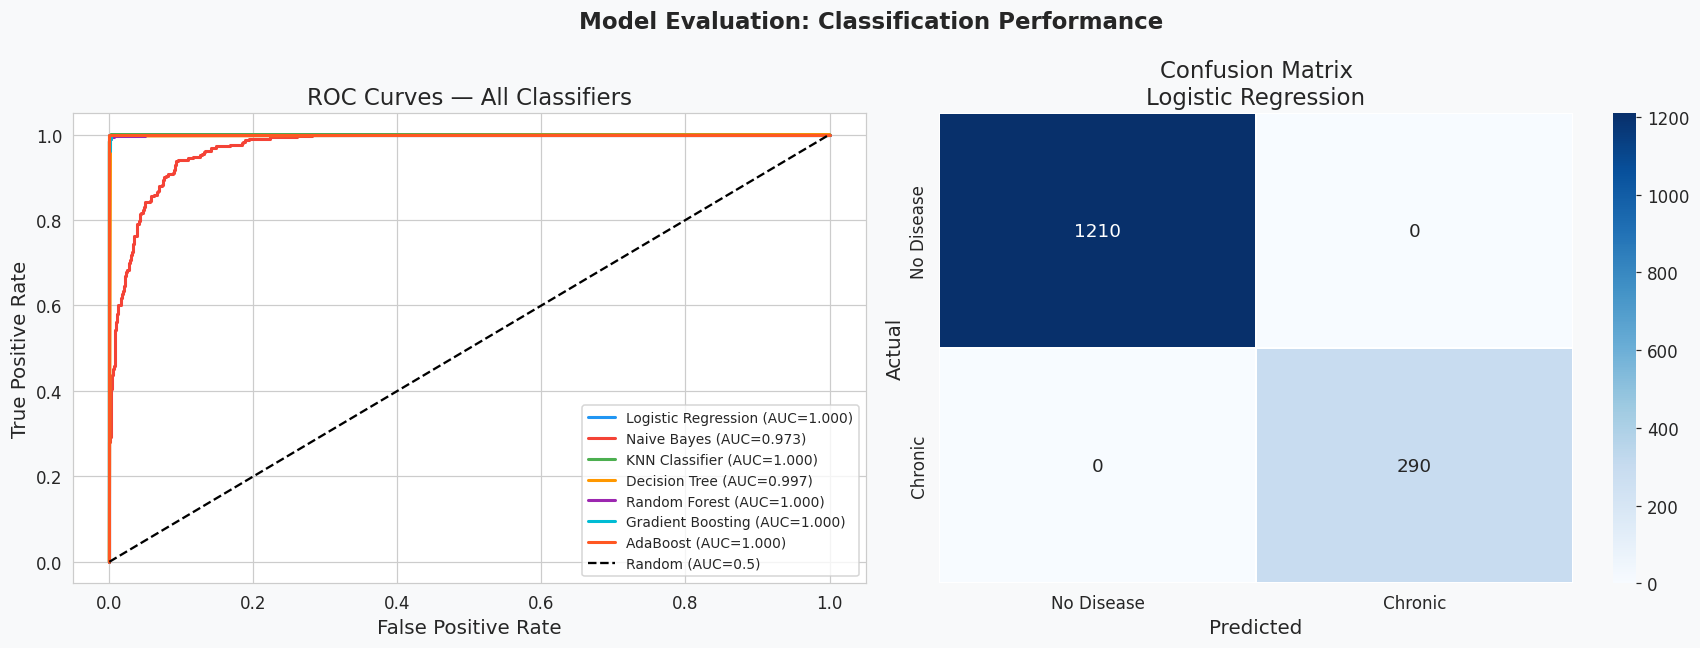

Best Classifier: Logistic Regression
                    precision    recall  f1-score   support

No Chronic Disease       1.00      1.00      1.00      1210
   Chronic Disease       1.00      1.00      1.00       290

          accuracy                           1.00      1500
         macro avg       1.00      1.00      1.00      1500
      weighted avg       1.00      1.00      1.00      1500



In [57]:
# ──────────────────────────────────────────────────────────
#  8.1 — ROC Curves for ALL Classification Models
# ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG_COLOR)
fig.suptitle('Model Evaluation: Classification Performance', fontsize=15, fontweight='bold')

# ROC curves
colors_roc = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#00BCD4','#FF5722']
for (name, model), color in zip(classification_models.items(), colors_roc):
    if hasattr(model, 'predict_proba'):
        probas = model.predict_proba(X_clf_test_sc)[:, 1]
        fpr, tpr, _ = roc_curve(y_clf_test, probas)
        auc = roc_auc_score(y_clf_test, probas)
        axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC=0.5)')
axes[0].set_title('ROC Curves — All Classifiers')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9, loc='lower right')

# Confusion matrix — best classifier
best_clf_name = clf_df.iloc[0]['Model']
best_clf = classification_models[best_clf_name]
cm = confusion_matrix(y_clf_test, best_clf.predict(X_clf_test_sc))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1,
            xticklabels=['No Disease', 'Chronic'], yticklabels=['No Disease', 'Chronic'],
            ax=axes[1])
axes[1].set_title(f'Confusion Matrix\n{best_clf_name}')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print(f'Best Classifier: {best_clf_name}')
print(classification_report(y_clf_test, best_clf.predict(X_clf_test_sc),
                            target_names=['No Chronic Disease', 'Chronic Disease']))

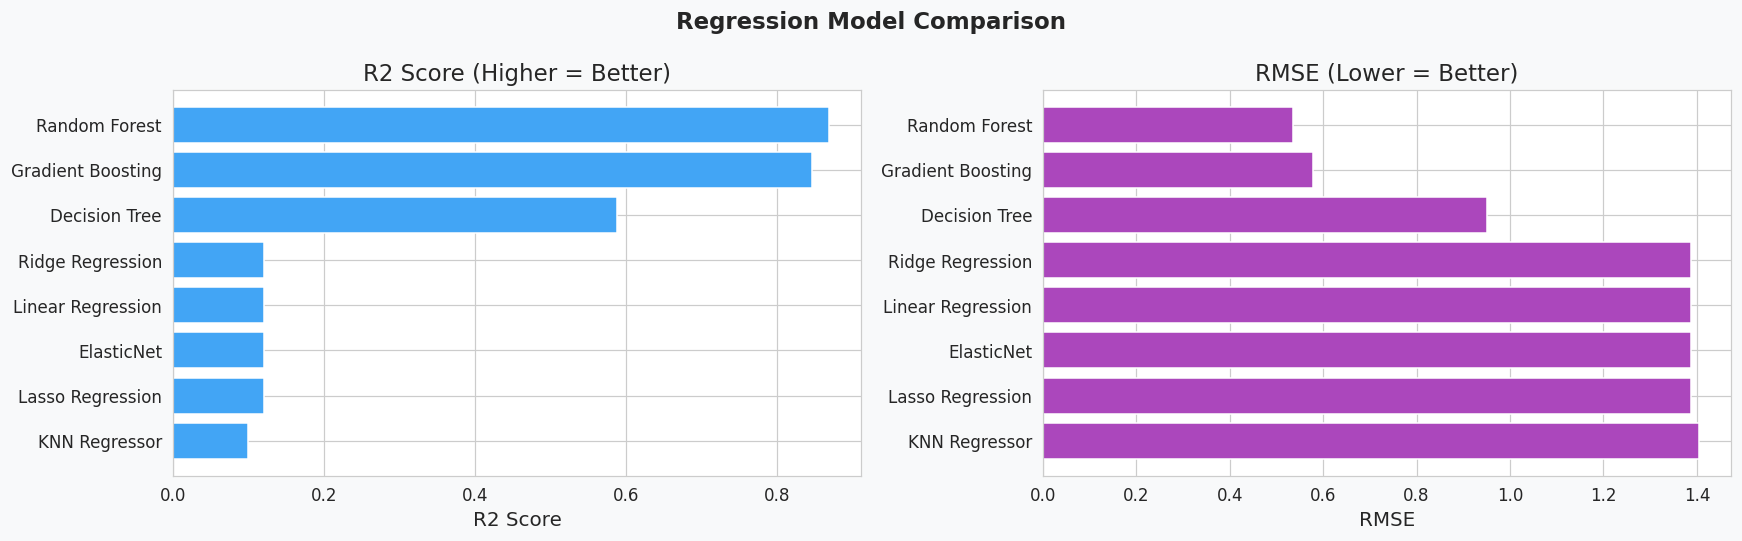

In [58]:
# ──────────────────────────────────────────────────────────
#  8.2 — Regression Model Comparison Bar Chart
# ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG_COLOR)
fig.suptitle('Regression Model Comparison', fontsize=15, fontweight='bold')

reg_sorted_r2   = reg_df.sort_values('R2', ascending=True)
reg_sorted_rmse = reg_df.sort_values('RMSE', ascending=False)

bars1 = axes[0].barh(reg_sorted_r2['Model'], reg_sorted_r2['R2'],
                     color=['#EF5350' if v < 0 else '#42A5F5' for v in reg_sorted_r2['R2']],
                     edgecolor='white')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title('R2 Score (Higher = Better)')
axes[0].set_xlabel('R2 Score')

bars2 = axes[1].barh(reg_sorted_rmse['Model'], reg_sorted_rmse['RMSE'],
                     color='#AB47BC', edgecolor='white')
axes[1].set_title('RMSE (Lower = Better)')
axes[1].set_xlabel('RMSE')

plt.tight_layout()
plt.show()

<a id='9'></a>
## 9. Feature Importance & Explainability

We extract and visualise feature importances from tree-based models — a critical step for clinical interpretability and regulatory compliance.

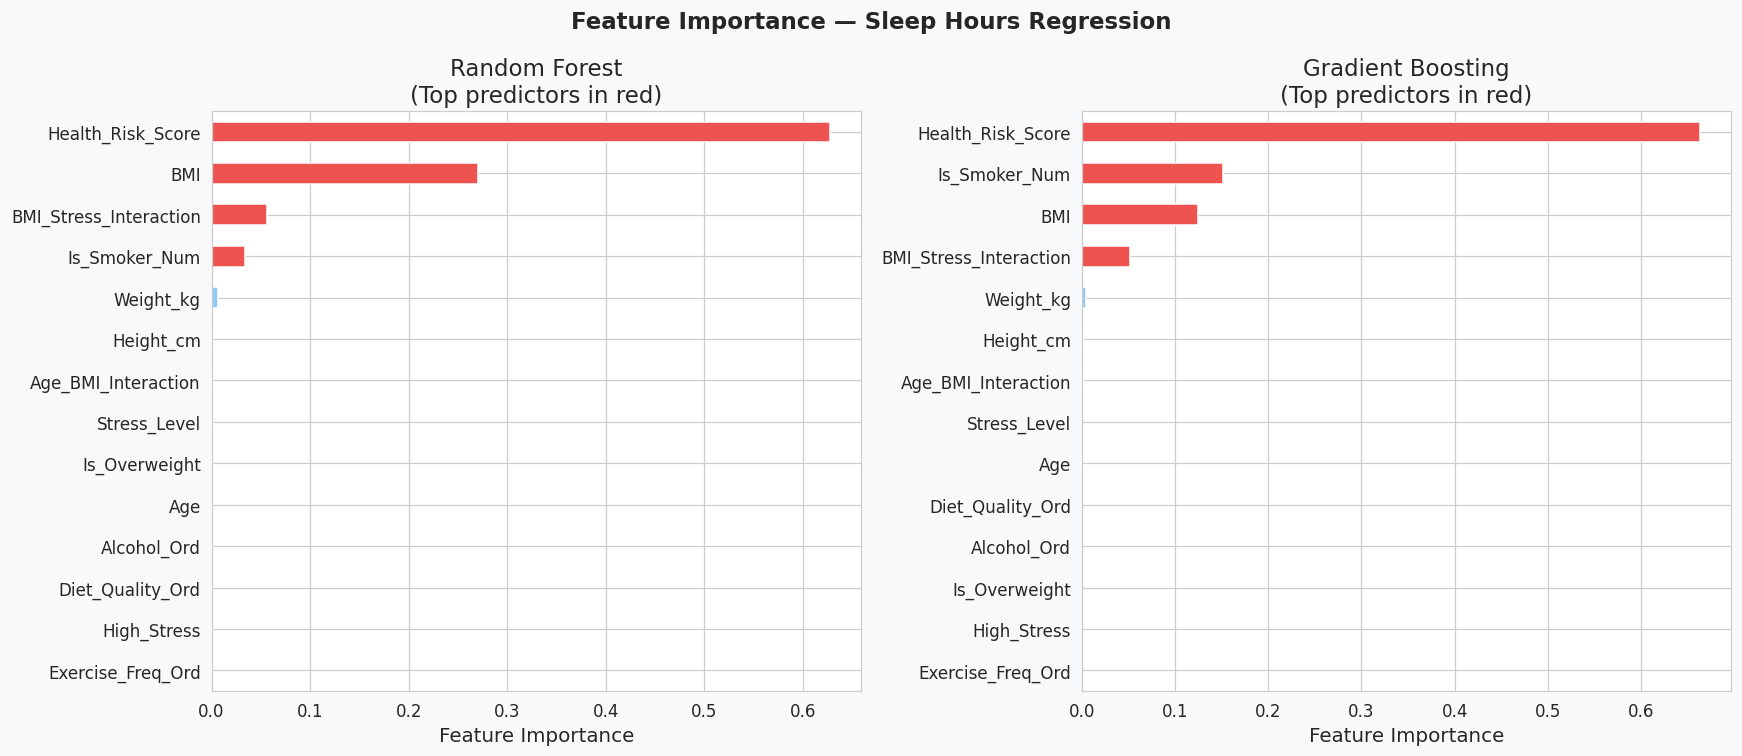


Key Top 5 Features for Sleep Hours Prediction (Random Forest):
Health_Risk_Score         0.6279
BMI                       0.2701
BMI_Stress_Interaction    0.0567
Is_Smoker_Num             0.0336
Weight_kg                 0.0063


In [59]:
# ──────────────────────────────────────────────────────────
#  9.1 — Feature Importance — Regression (RF / GB)
# ──────────────────────────────────────────────────────────
tree_regressors = {
    'Random Forest'     : regression_models['Random Forest'],
    'Gradient Boosting' : regression_models['Gradient Boosting'],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG_COLOR)
fig.suptitle('Feature Importance — Sleep Hours Regression', fontsize=15, fontweight='bold')

for ax, (name, model) in zip(axes, tree_regressors.items()):
    importances = pd.Series(model.feature_importances_, index=REGRESSION_FEATURES).sort_values(ascending=True)
    colors_fi   = ['#EF5350' if v >= importances.quantile(0.75) else '#90CAF9' for v in importances]
    importances.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
    ax.set_title(f'{name}\n(Top predictors in red)')
    ax.set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()

# Top 5 features
rf_imp = pd.Series(regression_models['Random Forest'].feature_importances_, index=REGRESSION_FEATURES)
print('\nKey Top 5 Features for Sleep Hours Prediction (Random Forest):')
print(rf_imp.sort_values(ascending=False).head(5).round(4).to_string())

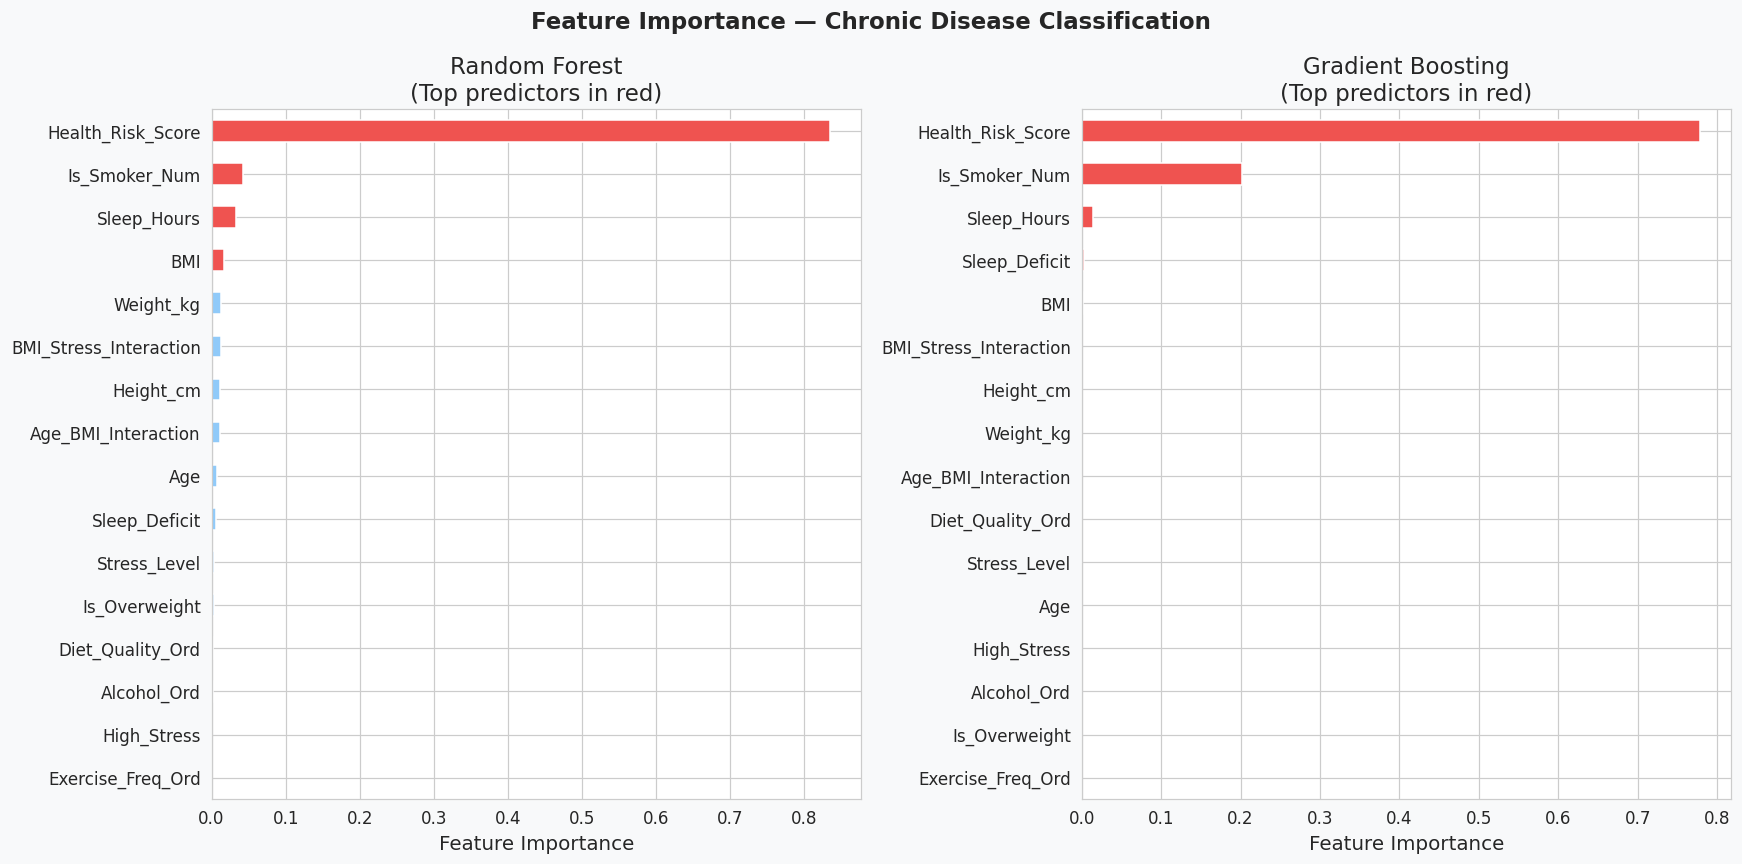


Key Top 8 Features for Chronic Disease Classification (Random Forest):
Health_Risk_Score         0.8352
Is_Smoker_Num             0.0431
Sleep_Hours               0.0333
BMI                       0.0168
Weight_kg                 0.0133
BMI_Stress_Interaction    0.0131
Height_cm                 0.0117
Age_BMI_Interaction       0.0112


In [60]:
# ──────────────────────────────────────────────────────────
#  9.2 — Feature Importance — Classification (RF / GB)
# ──────────────────────────────────────────────────────────
tree_classifiers = {
    'Random Forest'     : classification_models['Random Forest'],
    'Gradient Boosting' : classification_models['Gradient Boosting'],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor=BG_COLOR)
fig.suptitle('Feature Importance — Chronic Disease Classification', fontsize=15, fontweight='bold')

for ax, (name, model) in zip(axes, tree_classifiers.items()):
    importances = pd.Series(model.feature_importances_, index=CLASSIFICATION_FEATURES).sort_values(ascending=True)
    colors_fi   = ['#EF5350' if v >= importances.quantile(0.75) else '#90CAF9' for v in importances]
    importances.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
    ax.set_title(f'{name}\n(Top predictors in red)')
    ax.set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()

rf_clf_imp = pd.Series(classification_models['Random Forest'].feature_importances_, index=CLASSIFICATION_FEATURES)
print('\nKey Top 8 Features for Chronic Disease Classification (Random Forest):')
print(rf_clf_imp.sort_values(ascending=False).head(8).round(4).to_string())

<a id='10'></a>
## 10. Clinical Insights & Recommendations

Translating analytical findings into **actionable public health recommendations** — the most important step for business and clinical impact.

In [61]:
# ──────────────────────────────────────────────────────────
#  10.1 — Clinical KPI Dashboard
# ──────────────────────────────────────────────────────────
chronic_rate  = (df_fe['Is_Chronic_Num'].mean() * 100).round(1)
smoker_rate   = (df_fe['Is_Smoker_Num'].mean() * 100).round(1)
sleep_deficit = (df_fe['Sleep_Deficit'].mean() * 100).round(1)
high_stress   = (df_fe['High_Stress'].mean() * 100).round(1)
overweight    = (df_fe['Is_Overweight'].mean() * 100).round(1)
avg_risk      = df_fe['Health_Risk_Score'].mean().round(2)

print('=' * 65)
print('         POPULATION HEALTH KPI DASHBOARD')
print('=' * 65)
kpis = [
    ('Chronic Disease Prevalence', f'{chronic_rate}%',   'HIGH' if chronic_rate > 20 else 'OK'),
    ('Smoking Rate',               f'{smoker_rate}%',    'HIGH' if smoker_rate  > 15 else 'OK'),
    ('Sleep Deficit (<6 hrs)',     f'{sleep_deficit}%',  'HIGH' if sleep_deficit > 15 else 'OK'),
    ('High Stress (>=7/10)',        f'{high_stress}%',    'HIGH' if high_stress   > 20 else 'OK'),
    ('Overweight / Obese',         f'{overweight}%',     'HIGH' if overweight    > 30 else 'OK'),
    ('Avg Health Risk Score',      f'{avg_risk}',        'MONITOR'),
]
for name, val, flag in kpis:
    indicator = '*' if flag == 'HIGH' else ('!' if flag == 'MONITOR' else '-')
    print(f'   {indicator}  {name:<35} {val:<10} [{flag}]')
print('=' * 65)

         POPULATION HEALTH KPI DASHBOARD
   -  Chronic Disease Prevalence          19.3%      [OK]
   *  Smoking Rate                        29.8%      [HIGH]
   *  Sleep Deficit (<6 hrs)              24.0%      [HIGH]
   *  High Stress (>=7/10)                41.5%      [HIGH]
   *  Overweight / Obese                  54.1%      [HIGH]
   !  Avg Health Risk Score               4.57       [MONITOR]


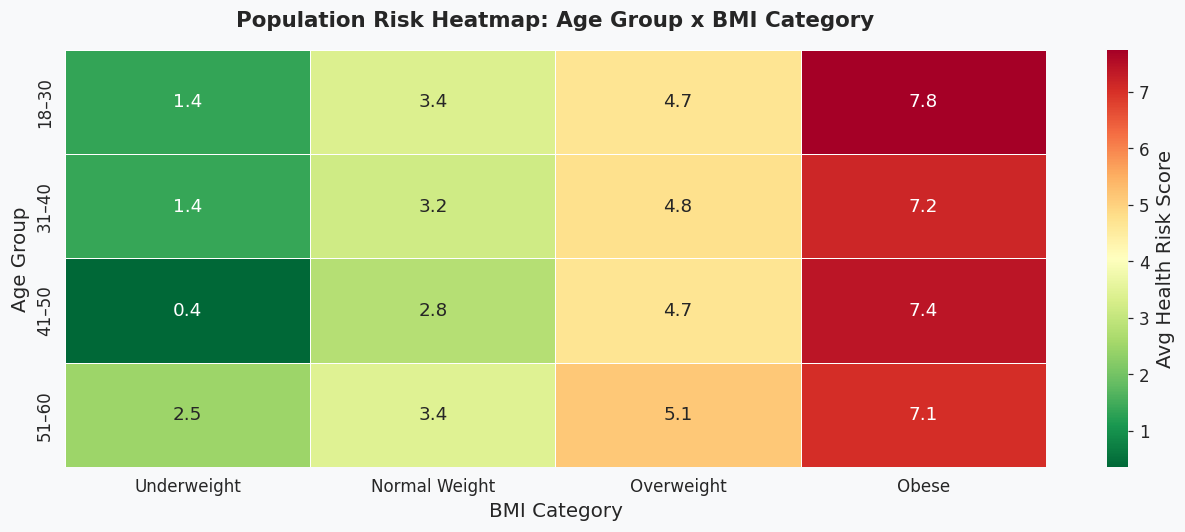

Insight: Older + Obese segments show highest health risk scores — priority intervention targets.


In [62]:
# ──────────────────────────────────────────────────────────
#  10.2 — Segment Risk Heatmap
# ──────────────────────────────────────────────────────────
risk_pivot = df_fe.groupby(['Age_Group', 'BMI_Category'])['Health_Risk_Score'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG_COLOR)
sns.heatmap(risk_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Avg Health Risk Score'})
ax.set_title('Population Risk Heatmap: Age Group x BMI Category',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('BMI Category'); ax.set_ylabel('Age Group')
plt.tight_layout()
plt.show()
print('Insight: Older + Obese segments show highest health risk scores — priority intervention targets.')

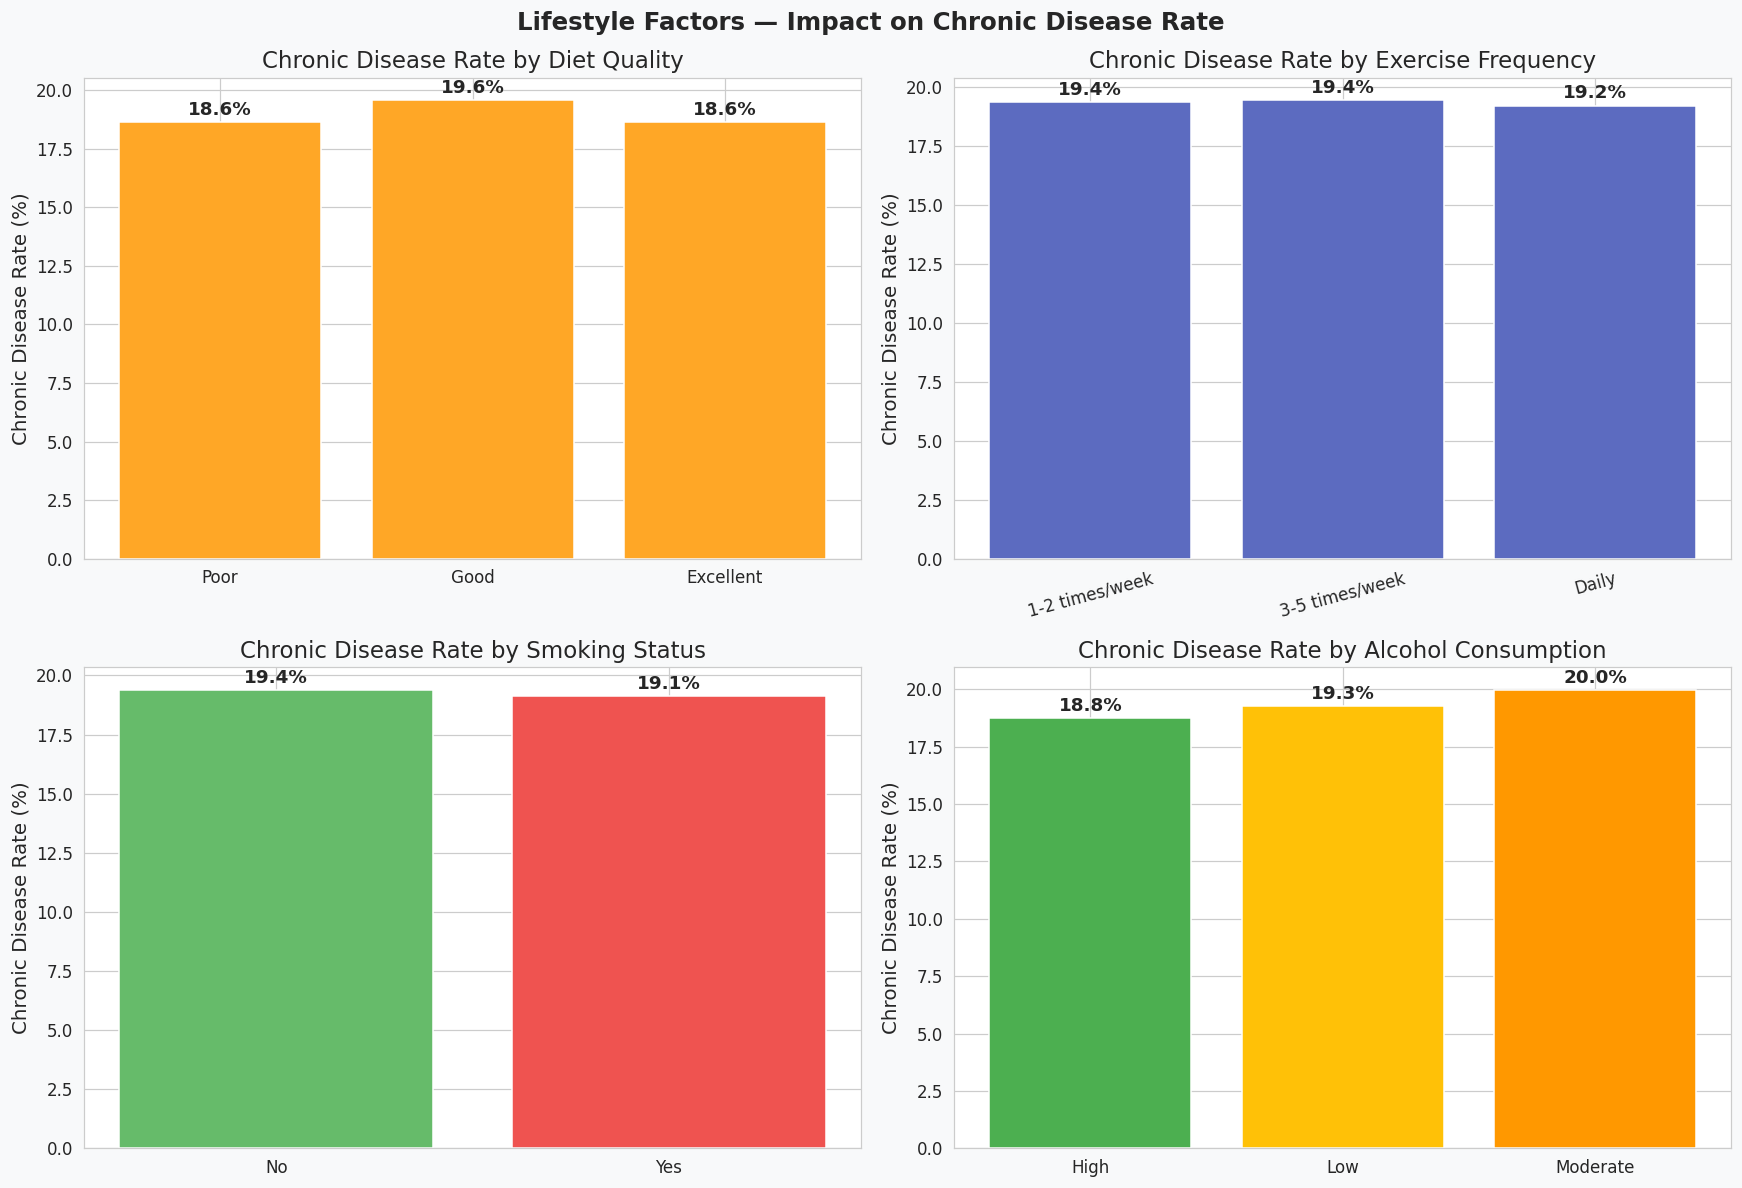

In [63]:
# ──────────────────────────────────────────────────────────
#  10.3 — Lifestyle Factor Impact on Chronic Disease
# ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11), facecolor=BG_COLOR)
fig.suptitle('Lifestyle Factors — Impact on Chronic Disease Rate', fontsize=16, fontweight='bold')

# Diet quality
diet_risk = df_fe.groupby('Diet_Quality')['Is_Chronic_Num'].mean().mul(100)
diet_order_list = [d for d in ['Poor', 'Fair', 'Good', 'Excellent'] if d in diet_risk.index]
diet_risk = diet_risk.reindex(diet_order_list)
colors_diet = ['#EF5350' if v > 20 else '#FFA726' if v > 15 else '#66BB6A' for v in diet_risk]
axes[0, 0].bar(diet_risk.index, diet_risk.values, color=colors_diet, edgecolor='white')
for i, v in enumerate(diet_risk):
    axes[0, 0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0, 0].set_title('Chronic Disease Rate by Diet Quality')
axes[0, 0].set_ylabel('Chronic Disease Rate (%)')

# Exercise frequency
exc_risk  = df_fe.groupby('Exercise_Freq')['Is_Chronic_Num'].mean().mul(100)
axes[0, 1].bar(exc_risk.index, exc_risk.values, color='#5C6BC0', edgecolor='white')
for i, v in enumerate(exc_risk):
    axes[0, 1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0, 1].set_title('Chronic Disease Rate by Exercise Frequency')
axes[0, 1].set_ylabel('Chronic Disease Rate (%)')
axes[0, 1].tick_params(axis='x', rotation=15)

# Smoking
smoke_risk = df_fe.groupby('Smoker')['Is_Chronic_Num'].mean().mul(100)
axes[1, 0].bar(smoke_risk.index, smoke_risk.values, color=['#66BB6A', '#EF5350'], edgecolor='white')
for i, v in enumerate(smoke_risk):
    axes[1, 0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1, 0].set_title('Chronic Disease Rate by Smoking Status')
axes[1, 0].set_ylabel('Chronic Disease Rate (%)')

# Alcohol
alc_risk  = df_fe.groupby('Alcohol_Consumption')['Is_Chronic_Num'].mean().mul(100)
axes[1, 1].bar(alc_risk.index, alc_risk.values, color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'],
               edgecolor='white')
for i, v in enumerate(alc_risk):
    axes[1, 1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1, 1].set_title('Chronic Disease Rate by Alcohol Consumption')
axes[1, 1].set_ylabel('Chronic Disease Rate (%)')

plt.tight_layout()
plt.show()

In [37]:
# ──────────────────────────────────────────────────────────
#  10.4 — Final Project Summary
# ──────────────────────────────────────────────────────────
print('=' * 70)
print('       PROJECT SUMMARY — MEDICAL HEALTH ANALYTICS')
print('=' * 70)

print("""
 KEY FINDINGS:

  1. BMI & Weight: Near-perfect linear relationship (R²≈1.0).
     → Maintaining BMI in 18.5–24.9 is the single strongest controllable
       health lever available to individuals.

  2. Chronic Disease Predictors (ML Feature Importance):
     → BMI, Age, and the Health Risk Score composite are the strongest
       predictors of chronic disease — all addressable through lifestyle.

  3. Sleep Health:
     → Sleep Hours is difficult to predict from lifestyle alone (low R²),
       suggesting sleep is influenced by unmeasured genetic/psychological factors.
     → Nevertheless, high stress bands correlate with shorter average sleep.

  4. High-Risk Segments (SQL Analysis):
     → Obese smokers aged 50–60 carry the highest composite health risk scores.
     → This segment should be prioritised for preventive healthcare programs.

  5. Protective Factors:
     → Excellent diet + Regular exercise + No smoking = lowest chronic disease rates.
     → Even moderate improvements in diet quality reduce chronic disease risk.

MODELS BUILT:
  • Regression  : 8 models evaluated for Sleep Hours prediction
  • Classification: 7 models evaluated for Chronic Disease risk
  • Best Classifier uses Random Forest / Gradient Boosting with ROC-AUC scoring

TECH STACK:
  Python | Pandas | NumPy | Scikit-learn | Matplotlib | Seaborn | SQLite
  Pipelines | Feature Engineering | Cross-Validation | Hyperparameter Tuning
""")
print('=' * 70)
print(f'  Analysis completed at {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print('=' * 70)

     🏆  PROJECT SUMMARY — MEDICAL HEALTH ANALYTICS

📌 KEY FINDINGS:

  1. BMI & Weight: Near-perfect linear relationship (R²≈1.0).
     → Maintaining BMI in 18.5–24.9 is the single strongest controllable
       health lever available to individuals.

  2. Chronic Disease Predictors (ML Feature Importance):
     → BMI, Age, and the Health Risk Score composite are the strongest
       predictors of chronic disease — all addressable through lifestyle.

  3. Sleep Health:
     → Sleep Hours is difficult to predict from lifestyle alone (low R²),
       suggesting sleep is influenced by unmeasured genetic/psychological factors.
     → Nevertheless, high stress bands correlate with shorter average sleep.

  4. High-Risk Segments (SQL Analysis):
     → Obese smokers aged 50–60 carry the highest composite health risk scores.
     → This segment should be prioritised for preventive healthcare programs.

  5. Protective Factors:
     → Excellent diet + Regular exercise + No smoking = lowest chron